Compare the numebr of escapes and number pof homings

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dill as pickle
from loguru import logger
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.rcParams.update({
    "font.size": 14,
    "font.family": "Arial",
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# Function to find all session directories
def find_all_sessions(base_path="Z:/Jasmine_Laurence/Experimental_Data"):
    """Find all session directories in the base path"""
    session_paths = []
    
    # Look for JAL directories
    mouse_dirs = glob.glob(os.path.join(base_path, "JAL*"))
    
    for mouse_dir in mouse_dirs:
        # Find all session directories within each mouse directory
        sessions = glob.glob(os.path.join(mouse_dir, "*"))
        for session in sessions:
            # Check if it's a directory and contains processed_data
            if os.path.isdir(session) and os.path.exists(os.path.join(session, "processed_data")):
                session_paths.append(session)
    
    return session_paths

# Function to load homings object
def load_homings_object(session_path):
    """Load homings object from a session"""
    homings_path = os.path.join(session_path, "processed_data", "homings", "homings_obj.pkl")
    
    if os.path.exists(homings_path):
        try:
            with open(homings_path, "rb") as f:
                return pickle.load(f)
        except Exception as e:
            logger.warning(f"Error loading homings object from {session_path}: {e}")
    
    return None

# Function to load escapes object
def load_escapes_object(session_path):
    """Load escapes object from a session, checking multiple possible paths"""
    possible_paths = [
        os.path.join(session_path, "processed_data", "escapes", "escapes_obj.pkl"),
        os.path.join(session_path, "processed_data", "escape", "escapes_obj.pkl"),
        os.path.join(session_path, "processed_data", "escapes_obj.pkl")
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    return pickle.load(f)
            except Exception as e:
                logger.warning(f"Error loading escapes object from {path}: {e}")
    
    return None

# Function to count homings and escapes
def count_homings_and_escapes(session_path):
    """Count the number of homings and escapes in a session"""
    session_name = os.path.basename(session_path)
    mouse_name = os.path.basename(os.path.dirname(session_path))
    
    # Load homings and escapes objects
    homings_obj = load_homings_object(session_path)
    escapes_obj = load_escapes_object(session_path)
    
    # Count homings if object exists
    num_homings = 0
    if homings_obj is not None and hasattr(homings_obj, "onset_frames"):
        num_homings = len(homings_obj.onset_frames)
    
    # Count escapes if object exists
    num_escapes = 0
    if escapes_obj is not None and hasattr(escapes_obj, "escape_onset_frames"):
        num_escapes = len(escapes_obj.escape_onset_frames)
    
    return {
        "session_path": session_path,
        "session_name": session_name,
        "mouse_name": mouse_name,
        "num_homings": num_homings,
        "num_escapes": num_escapes
    }

# Main function to analyze all sessions
def analyze_homings_vs_escapes():
    """Analyze homings vs escapes across all sessions and create a box plot"""
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Count homings and escapes for each session
    logger.info("Counting homings and escapes...")
    results = []
    for session_path in session_paths:
        results.append(count_homings_and_escapes(session_path))
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Print summary statistics
    print("Summary statistics:")
    print(f"Total sessions: {len(df)}")
    print(f"Sessions with homings: {len(df[df.num_homings > 0])}")
    print(f"Sessions with escapes: {len(df[df.num_escapes > 0])}")
    print(f"Average homings per session: {df.num_homings.mean():.2f}")
    print(f"Average escapes per session: {df.num_escapes.mean():.2f}")
    
    # Create the box plot
    logger.info("Creating box plot...")
    plot_data = pd.melt(df[["session_name", "num_homings", "num_escapes"]], 
                        id_vars=["session_name"], 
                        value_vars=["num_homings", "num_escapes"],
                        var_name="Behavior Type", value_name="Count")
    
    # Rename variables for better plot labels
    plot_data["Behavior Type"] = plot_data["Behavior Type"].replace({
        "num_homings": "Homings",
        "num_escapes": "Escapes"
    })
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Create box plot
    ax = sns.boxplot(x="Behavior Type", y="Count", data=plot_data, 
                    palette=["lightblue", "lightcoral"])
    
    # Add swarm plot to show individual points
    sns.swarmplot(x="Behavior Type", y="Count", data=plot_data, 
                color="dimgrey", alpha=0.7)
    
    # Add statistical annotation
    from scipy.stats import wilcoxon
    stat_result = wilcoxon(df.num_homings, df.num_escapes)
    p_value = stat_result.pvalue
    
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "n.s."
    
    y_max = plot_data["Count"].max() * 1.1
    plt.plot([0, 1], [y_max, y_max], 'k-', linewidth=1.5)
    plt.text(0.5, y_max * 1.05, significance, ha='center', va='center', fontsize=18)
    
    # Add labels and formatting
    plt.title("Comparison of Homings vs Escapes Across Sessions", fontweight="bold")
    plt.ylabel("Count per Session")
    plt.xlabel("")
    
    # Remove top and right spines
    sns.despine()
    
    # Save the figure
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "homings_vs_escapes.eps"), format='eps', bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(save_path, "homings_vs_escapes.png"), format='png', bbox_inches='tight', dpi=300)
    
    plt.show()
    
    # Return the DataFrame for further analysis
    return df

# Run the analysis
homings_vs_escapes_df = analyze_homings_vs_escapes()

2025-07-16 15:51:05.021 | INFO     | __main__:analyze_homings_vs_escapes:106 - Finding all session paths...
2025-07-16 15:51:05.187 | INFO     | __main__:analyze_homings_vs_escapes:108 - Found 47 session paths
2025-07-16 15:51:05.187 | INFO     | __main__:analyze_homings_vs_escapes:111 - Counting homings and escapes...
2025-07-16 15:51:06.467 | INFO     | __main__:analyze_homings_vs_escapes:128 - Creating box plot...


Summary statistics:
Total sessions: 47
Sessions with homings: 35
Sessions with escapes: 38
Average homings per session: 46.60
Average escapes per session: 6.57


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [3]:
def analyze_homings_vs_escapes():
    """Analyze homings vs escapes across all sessions and create a bar plot for publication"""
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Count homings and escapes for each session
    logger.info("Counting homings and escapes...")
    results = []
    for session_path in session_paths:
        results.append(count_homings_and_escapes(session_path))
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Print summary statistics
    print("Summary statistics:")
    print(f"Total sessions: {len(df)}")
    print(f"Sessions with homings: {len(df[df.num_homings > 0])}")
    print(f"Sessions with escapes: {len(df[df.num_escapes > 0])}")
    print(f"Average homings per session: {df.num_homings.mean():.2f}")
    print(f"Average escapes per session: {df.num_escapes.mean():.2f}")
    
    # Calculate statistics for bar plot
    behavior_types = ["Homings", "Escapes"]
    means = [df.num_homings.mean(), df.num_escapes.mean()]
    sems = [df.num_homings.sem(), df.num_escapes.sem()]
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 16,
        "font.family": "Arial",
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "savefig.dpi": 300,
        "figure.dpi": 150
    })
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create bar plot with error bars
    bars = ax.bar(
        np.arange(len(behavior_types)), 
        means, 
        yerr=sems,
        width=0.6, 
        capsize=8, 
        color=['#4878D0', '#EE854A'], 
        edgecolor='black',
        linewidth=1.5,
        error_kw={'elinewidth': 1.5, 'capthick': 1.5}
    )
    
    # Add individual data points
    for i, behavior in enumerate(behavior_types):
        if behavior == "Homings":
            data = df.num_homings
        else:
            data = df.num_escapes
        
        # Add jittered points
        jitter = np.random.normal(0, 0.05, size=len(data))
        ax.scatter(
            i + jitter, 
            data, 
            color='dimgrey', 
            alpha=0.5, 
            s=40, 
            zorder=3
        )
    
    # Add statistical annotation
    from scipy.stats import wilcoxon
    stat_result = wilcoxon(df.num_homings, df.num_escapes)
    p_value = stat_result.pvalue
    
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "n.s."
    
    # Calculate position for significance bar
    y_max = max(means) + max(sems) + (max(means) * 0.2)
    ax.plot([0, 1], [y_max, y_max], 'k-', linewidth=2)
    ax.text(0.5, y_max * 1.05, significance, ha='center', va='center', fontsize=20, fontweight='bold')
    
    # Add exact p-value
    p_text = f"p = {p_value:.3f}" if p_value >= 0.001 else "p < 0.001"
    ax.text(0.5, y_max * 0.92, p_text, ha='center', va='center', fontsize=14)
    
    # Set axis labels and title
    ax.set_xticks(np.arange(len(behavior_types)))
    ax.set_xticklabels(behavior_types, fontweight='bold')
    ax.set_ylabel("Count per Session", fontweight='bold')
    ax.set_title("Comparison of Homings vs Escapes", fontweight="bold")
    
    # Set y-axis limits with some padding
    ax.set_ylim(0, y_max * 1.15)
    
    # Add value labels on top of bars
    for i, (bar, mean) in enumerate(zip(bars, means)):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean + sems[i] + (max(means) * 0.03),
            f"{mean:.1f}",
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold'
        )
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=6)
    
    # Add grid lines for y-axis only
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    # Tight layout to maximize figure space
    plt.tight_layout()
    
    # Save the figure with high resolution
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "homings_vs_escapes_barplot.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "homings_vs_escapes_barplot.png"), format='png', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "homings_vs_escapes_barplot.pdf"), format='pdf', bbox_inches='tight')
    
    plt.show()
    
    # Return the DataFrame for further analysis
    return df

In [4]:
analyze_homings_vs_escapes()

2025-07-16 15:51:09.029 | INFO     | __main__:analyze_homings_vs_escapes:4 - Finding all session paths...
2025-07-16 15:51:09.133 | INFO     | __main__:analyze_homings_vs_escapes:6 - Found 47 session paths
2025-07-16 15:51:09.133 | INFO     | __main__:analyze_homings_vs_escapes:9 - Counting homings and escapes...
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Summary statistics:
Total sessions: 47
Sessions with homings: 35
Sessions with escapes: 38
Average homings per session: 46.60
Average escapes per session: 6.57


,session_path,session_name,mouse_name,num_homings,num_escapes
0,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_baseline_2023_08_17T13_41_44,JAL004,3,1
1,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_flipppuf19sept_2023_09_19T14_10_56,JAL004,76,18
2,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_flip_2023_09_03T12_04_16,JAL004,67,8
3,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_flip_puff2_2023_09_11T09_32_25,JAL004,43,7
4,Z:/Jasmine_Laurence/Experimental_Data\JAL004\0...,004_mush1_2023_08_22T13_13_41,JAL004,0,0
5,Z:/Jasmine_Laurence/Experimental_Data\JAL004\J...,JAL004_flip_rotated_2023_08_28T09_36_04,JAL004,31,3
6,Z:/Jasmine_Laurence/Experimental_Data\JAL003\0...,003_003puftrotato3_2023_09_07T12_23_47,JAL003,130,23
7,Z:/Jasmine_Laurence/Experimental_Data\JAL003\0...,003_baseline_2023_08_17T08_16_46,JAL003,5,3
8,Z:/Jasmine_Laurence/Experimental_Data\JAL003\0...,003_flippuff2_2023_09_04T13_38_31,JAL003,89,13
9,Z:/Jasmine_Laurence/Experimental_Data\JAL003\0...,003_flip_1Sept_2023_09_01T16_23_39,JAL003,109,6


In [5]:
def analyze_homings_trend_by_mouse():
    """
    Analyze whether the number of homings increases across sessions for each mouse.
    Creates a multi-panel plot showing trends for each individual mouse.
    Excludes JAL001 and JAL002 from the analysis.
    """
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Count homings and escapes for each session
    logger.info("Counting homings and escapes...")
    results = []
    for session_path in session_paths:
        session_data = count_homings_and_escapes(session_path)
        
        # Extract date information from session path
        session_name = session_data["session_name"]
        try:
            # First look for ISO format date without parsing time components
            import re
            # Extract just the date part to avoid timezone issues
            date_match = re.search(r'(\d{4})[-_](\d{2})[-_](\d{2})', session_name)
            if date_match:
                year, month, day = date_match.groups()
                session_data["session_date"] = pd.Timestamp(year=int(year), month=int(month), day=int(day))
                logger.info(f"Extracted date {session_data['session_date']} from {session_name}")
            else:
                # Alternative: try to extract only numbers which might be date indicators
                numbers = re.findall(r'\d+', session_name)
                if numbers:
                    # If we couldn't extract a date, fall back to using the last number as order
                    session_data["session_order"] = int(numbers[-1])
                    logger.info(f"Using number {session_data['session_order']} for ordering from {session_name}")
                else:
                    session_data["session_order"] = 0
                    logger.info(f"No date or order information found in {session_name}")
        except Exception as e:
            logger.warning(f"Error extracting date from {session_name}: {e}")
            session_data["session_order"] = 0
            
        results.append(session_data)
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Filter out JAL001 and JAL002
    logger.info("Filtering out JAL001 and JAL002 from analysis...")
    excluded_mice = ["JAL001", "JAL002"]
    df_filtered = df[~df["mouse_name"].isin(excluded_mice)]
    logger.info(f"Removed {len(df) - len(df_filtered)} sessions from excluded mice")
    
    # Group sessions by mouse
    mouse_groups = df_filtered.groupby("mouse_name")
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 12,
        "font.family": "Arial",
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    
    # Determine layout for subplots based on number of mice
    n_mice = len(mouse_groups)
    n_cols = min(3, n_mice)  # Maximum 3 columns
    n_rows = (n_mice + n_cols - 1) // n_cols  # Ceiling division
    
    # Create figure with non-shared axes and increased width
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharex=False, sharey=False)
    if n_rows * n_cols == 1:  # Handle single subplot case
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Track overall statistics for summary
    all_trends = []
    
    # Plot each mouse's data in a separate subplot
    for i, (mouse_name, mouse_data) in enumerate(mouse_groups):
        ax = axes[i]
        
        # Sort sessions by date if available, otherwise use order indicator
        if "session_date" in mouse_data.columns and not mouse_data["session_date"].isna().all():
            # Filter out NaN values before sorting
            valid_dates = mouse_data.dropna(subset=["session_date"])
            if not valid_dates.empty:
                # Sort the data with valid dates
                mouse_data = mouse_data.sort_values("session_date", na_position="last")
                # Add a column showing days since first session for better x-axis labeling
                first_date = mouse_data["session_date"].min()
                # Calculate days since first session only for rows with valid dates
                mouse_data.loc[~mouse_data["session_date"].isna(), "days_since_first"] = (
                    mouse_data.loc[~mouse_data["session_date"].isna(), "session_date"] - first_date
                ).dt.days
                # For rows with missing dates, use sequential numbers after the last valid day
                if mouse_data["session_date"].isna().any():
                    max_days = mouse_data["days_since_first"].max()
                    for idx, row in mouse_data[mouse_data["session_date"].isna()].iterrows():
                        max_days += 1
                        mouse_data.loc[idx, "days_since_first"] = max_days
                
                x_values = mouse_data["days_since_first"].values
                x_labels = [f"{int(x)}" for x in x_values]
            else:
                # All dates are NaN, fall back to sequential numbering
                x_values = range(len(mouse_data))
                x_labels = [f"{i+1}" for i in x_values]
        elif "session_order" in mouse_data.columns:
            mouse_data = mouse_data.sort_values("session_order")
            x_values = range(len(mouse_data))
            x_labels = [f"{i+1}" for i in x_values]
        else:
            # No ordering information available, use sequential numbering
            x_values = range(len(mouse_data))
            x_labels = [f"{i+1}" for i in x_values]
        
        # Plot homings count as connected points
        ax.plot(x_values, mouse_data["num_homings"].values, 'o-', color='#4878D0', 
                linewidth=2, markersize=8, label='Homings')
        
        # Plot escapes count for reference
        ax.plot(x_values, mouse_data["num_escapes"].values, 's--', color='#EE854A', 
                linewidth=1.5, markersize=6, alpha=0.7, label='Escapes')
        
        # Add trend line for homings
        if len(mouse_data) > 1:  # Need at least 2 points for a trend
            from scipy.stats import linregress
            
            # Use the actual day values for calculating the regression
            slope, intercept, r_value, p_value, std_err = linregress(x_values, mouse_data["num_homings"].values)
            
            # Save trend information
            all_trends.append({
                "mouse": mouse_name,
                "slope": slope,
                "p_value": p_value,
                "r_squared": r_value**2,
                "sessions": len(mouse_data)
            })
            
            # Plot trend line across the full x-range using actual day values
            x_min = min(x_values)
            x_max = max(x_values)
            trend_x = np.array([x_min, x_max])
            trend_y = intercept + slope * trend_x
            ax.plot(trend_x, trend_y, 'k-', linewidth=1.5, alpha=0.7)
            
            # Add trend statistics
            trend_text = f"Slope: {slope:.2f}\nR²: {r_value**2:.2f}\np: {p_value:.3f}"
            trend_color = 'green' if slope > 0 else 'red' if slope < 0 else 'black'
            ax.text(0.05, 0.95, trend_text, transform=ax.transAxes, va='top', 
                    fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
                    color=trend_color)
        
        # Format the plot
        ax.set_title(f"Mouse {mouse_name}", fontweight='bold')
        ax.set_ylabel("Count")
        
        # Use chronological labels for x-axis
        if "session_date" in mouse_data.columns and not mouse_data["session_date"].isna().all():
            ax.set_xlabel("Days Since First Session")
        else:
            ax.set_xlabel("Session Number")
        
        # Set x-ticks and labels
        if len(x_values) > 8:  # If many tick labels, show only a subset
            step = len(x_values) // 5 + 1
            show_indices = list(range(0, len(x_values), step))
            if len(x_values) - 1 not in show_indices:
                show_indices.append(len(x_values) - 1)  # Always include the last one
            
            ax.set_xticks([x_values[i] for i in show_indices])
            ax.set_xticklabels([x_labels[i] for i in show_indices], rotation=90, ha='center')
        else:
            # If not too many, show all but with vertical rotation for better spacing
            ax.set_xticks(x_values)
            ax.set_xticklabels(x_labels, rotation=90, ha='center')
        
        # Add legend
        ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.8)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add grid for readability
        ax.grid(True, linestyle='--', alpha=0.3)
    
    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    # Calculate overall statistics (but don't show as title)
    increasing = sum(1 for t in all_trends if t['slope'] > 0)
    decreasing = sum(1 for t in all_trends if t['slope'] < 0)
    significant = sum(1 for t in all_trends if t['p_value'] < 0.05)
    
    # Note: Removed the fig.suptitle line to eliminate the main title
    
    # Adjust layout with more bottom padding for x-labels
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Make room for x-labels
    
    # Save the figure with high resolution
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "homings_trend_by_mouse_filtered.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "homings_trend_by_mouse_filtered.png"), format='png', bbox_inches='tight', dpi=300)
    
    # Create a summary dataframe of trends
    trend_df = pd.DataFrame(all_trends)
    
    # Print summary statistics
    print("\nTrend Analysis Summary (excluding JAL001 and JAL002):")
    print(f"Number of mice: {len(trend_df)}")
    print(f"Mice with increasing homings: {increasing} ({increasing/len(trend_df)*100:.1f}%)")
    print(f"Mice with decreasing homings: {decreasing} ({decreasing/len(trend_df)*100:.1f}%)")
    print(f"Mice with significant trends (p<0.05): {significant} ({significant/len(trend_df)*100:.1f}%)")
    
    plt.show()
    
    return df_filtered, trend_df

In [6]:
def analyze_homings_trend_by_mouse():
    """
    Analyze whether the number of homings increases across sessions for each mouse.
    Creates a multi-panel plot showing trends for each individual mouse.
    Excludes JAL001 and JAL002 from the analysis.
    """
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Count homings and escapes for each session
    logger.info("Counting homings and escapes...")
    results = []
    for session_path in session_paths:
        session_data = count_homings_and_escapes(session_path)
        
        # Extract date information from session path
        session_name = session_data["session_name"]
        try:
            import re
            date_match = re.search(r'(\d{4})[-_](\d{2})[-_](\d{2})', session_name)
            if date_match:
                year, month, day = date_match.groups()
                session_data["session_date"] = pd.Timestamp(year=int(year), month=int(month), day=int(day))
                logger.info(f"Extracted date {session_data['session_date']} from {session_name}")
            else:
                numbers = re.findall(r'\d+', session_name)
                if numbers:
                    session_data["session_order"] = int(numbers[-1])
                    logger.info(f"Using number {session_data['session_order']} for ordering from {session_name}")
                else:
                    session_data["session_order"] = 0
                    logger.info(f"No date or order information found in {session_name}")
        except Exception as e:
            logger.warning(f"Error extracting date from {session_name}: {e}")
            session_data["session_order"] = 0
            
        results.append(session_data)
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Filter out JAL001 and JAL002
    logger.info("Filtering out JAL001 and JAL002 from analysis...")
    excluded_mice = ["JAL001", "JAL002"]
    df_filtered = df[~df["mouse_name"].isin(excluded_mice)]
    logger.info(f"Removed {len(df) - len(df_filtered)} sessions from excluded mice")
    
    # Group sessions by mouse
    mouse_groups = df_filtered.groupby("mouse_name")
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 12,
        "font.family": "Arial",
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    })
    
    # Fixed layout: 3 rows, 2 columns
    n_rows, n_cols = 3, 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharex=False, sharey=False)
    axes = axes.flatten()
    
    # Plot each mouse's data in a separate subplot
    for i, (mouse_name, mouse_data) in enumerate(mouse_groups):
        ax = axes[i]
        # Sort sessions by date if available, otherwise use order indicator
        if "session_date" in mouse_data.columns and not mouse_data["session_date"].isna().all():
            valid_dates = mouse_data.dropna(subset=["session_date"])
            if not valid_dates.empty:
                mouse_data = mouse_data.sort_values("session_date", na_position="last")
                first_date = mouse_data["session_date"].min()
                mouse_data.loc[~mouse_data["session_date"].isna(), "days_since_first"] = (
                    mouse_data.loc[~mouse_data["session_date"].isna(), "session_date"] - first_date
                ).dt.days
                if mouse_data["session_date"].isna().any():
                    max_days = mouse_data["days_since_first"].max()
                    for idx, row in mouse_data[mouse_data["session_date"].isna()].iterrows():
                        max_days += 1
                        mouse_data.loc[idx, "days_since_first"] = max_days
                x_values = mouse_data["days_since_first"].values
                x_labels = [f"{int(x)}" for x in x_values]
            else:
                x_values = range(len(mouse_data))
                x_labels = [f"{i+1}" for i in x_values]
        elif "session_order" in mouse_data.columns:
            mouse_data = mouse_data.sort_values("session_order")
            x_values = range(len(mouse_data))
            x_labels = [f"{i+1}" for i in x_values]
        else:
            x_values = range(len(mouse_data))
            x_labels = [f"{i+1}" for i in x_values]
        
        # Plot homings count as connected points
        ax.plot(x_values, mouse_data["num_homings"].values, 'o-', color='#4878D0', 
                linewidth=2, markersize=8, label='Homings')
        # Plot escapes count for reference
        ax.plot(x_values, mouse_data["num_escapes"].values, 's--', color='#EE854A', 
                linewidth=1.5, markersize=6, alpha=0.7, label='Escapes')
        
        # Format the plot
        ax.set_title(f"Mouse {mouse_name}", fontweight='bold')
        ax.set_ylabel("Count")
        if "session_date" in mouse_data.columns and not mouse_data["session_date"].isna().all():
            ax.set_xlabel("Days Since First Session")
        else:
            ax.set_xlabel("Session Number")
        if len(x_values) > 8:
            step = len(x_values) // 5 + 1
            show_indices = list(range(0, len(x_values), step))
            if len(x_values) - 1 not in show_indices:
                show_indices.append(len(x_values) - 1)
            ax.set_xticks([x_values[i] for i in show_indices])
            ax.set_xticklabels([x_labels[i] for i in show_indices], rotation=90, ha='center')
        else:
            ax.set_xticks(x_values)
            ax.set_xticklabels(x_labels, rotation=90, ha='center')
        ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)
    
    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    
    # ensure no grids
    plt.grid(False)
    
    plt.savefig(os.path.join(save_path, "homings_trend_by_mouse_filtered.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "homings_trend_by_mouse_filtered.png"), format='png', bbox_inches='tight', dpi=300)
    plt.show()

2025-07-16 15:51:12.135 | INFO     | __main__:analyze_homings_trend_by_mouse:8 - Finding all session paths...
2025-07-16 15:51:12.271 | INFO     | __main__:analyze_homings_trend_by_mouse:10 - Found 47 session paths
2025-07-16 15:51:12.272 | INFO     | __main__:analyze_homings_trend_by_mouse:13 - Counting homings and escapes...
2025-07-16 15:51:12.287 | INFO     | __main__:analyze_homings_trend_by_mouse:26 - Extracted date 2023-08-17 00:00:00 from 004_baseline_2023_08_17T13_41_44
2025-07-16 15:51:12.309 | INFO     | __main__:analyze_homings_trend_by_mouse:26 - Extracted date 2023-09-19 00:00:00 from 004_flipppuf19sept_2023_09_19T14_10_56
2025-07-16 15:51:12.331 | INFO     | __main__:analyze_homings_trend_by_mouse:26 - Extracted date 2023-09-03 00:00:00 from 004_flip_2023_09_03T12_04_16
2025-07-16 15:51:12.345 | INFO     | __main__:analyze_homings_trend_by_mouse:26 - Extracted date 2023-09-11 00:00:00 from 004_flip_puff2_2023_09_11T09_32_25
2025-07-16 15:51:12.349 | INFO     | __main__:a

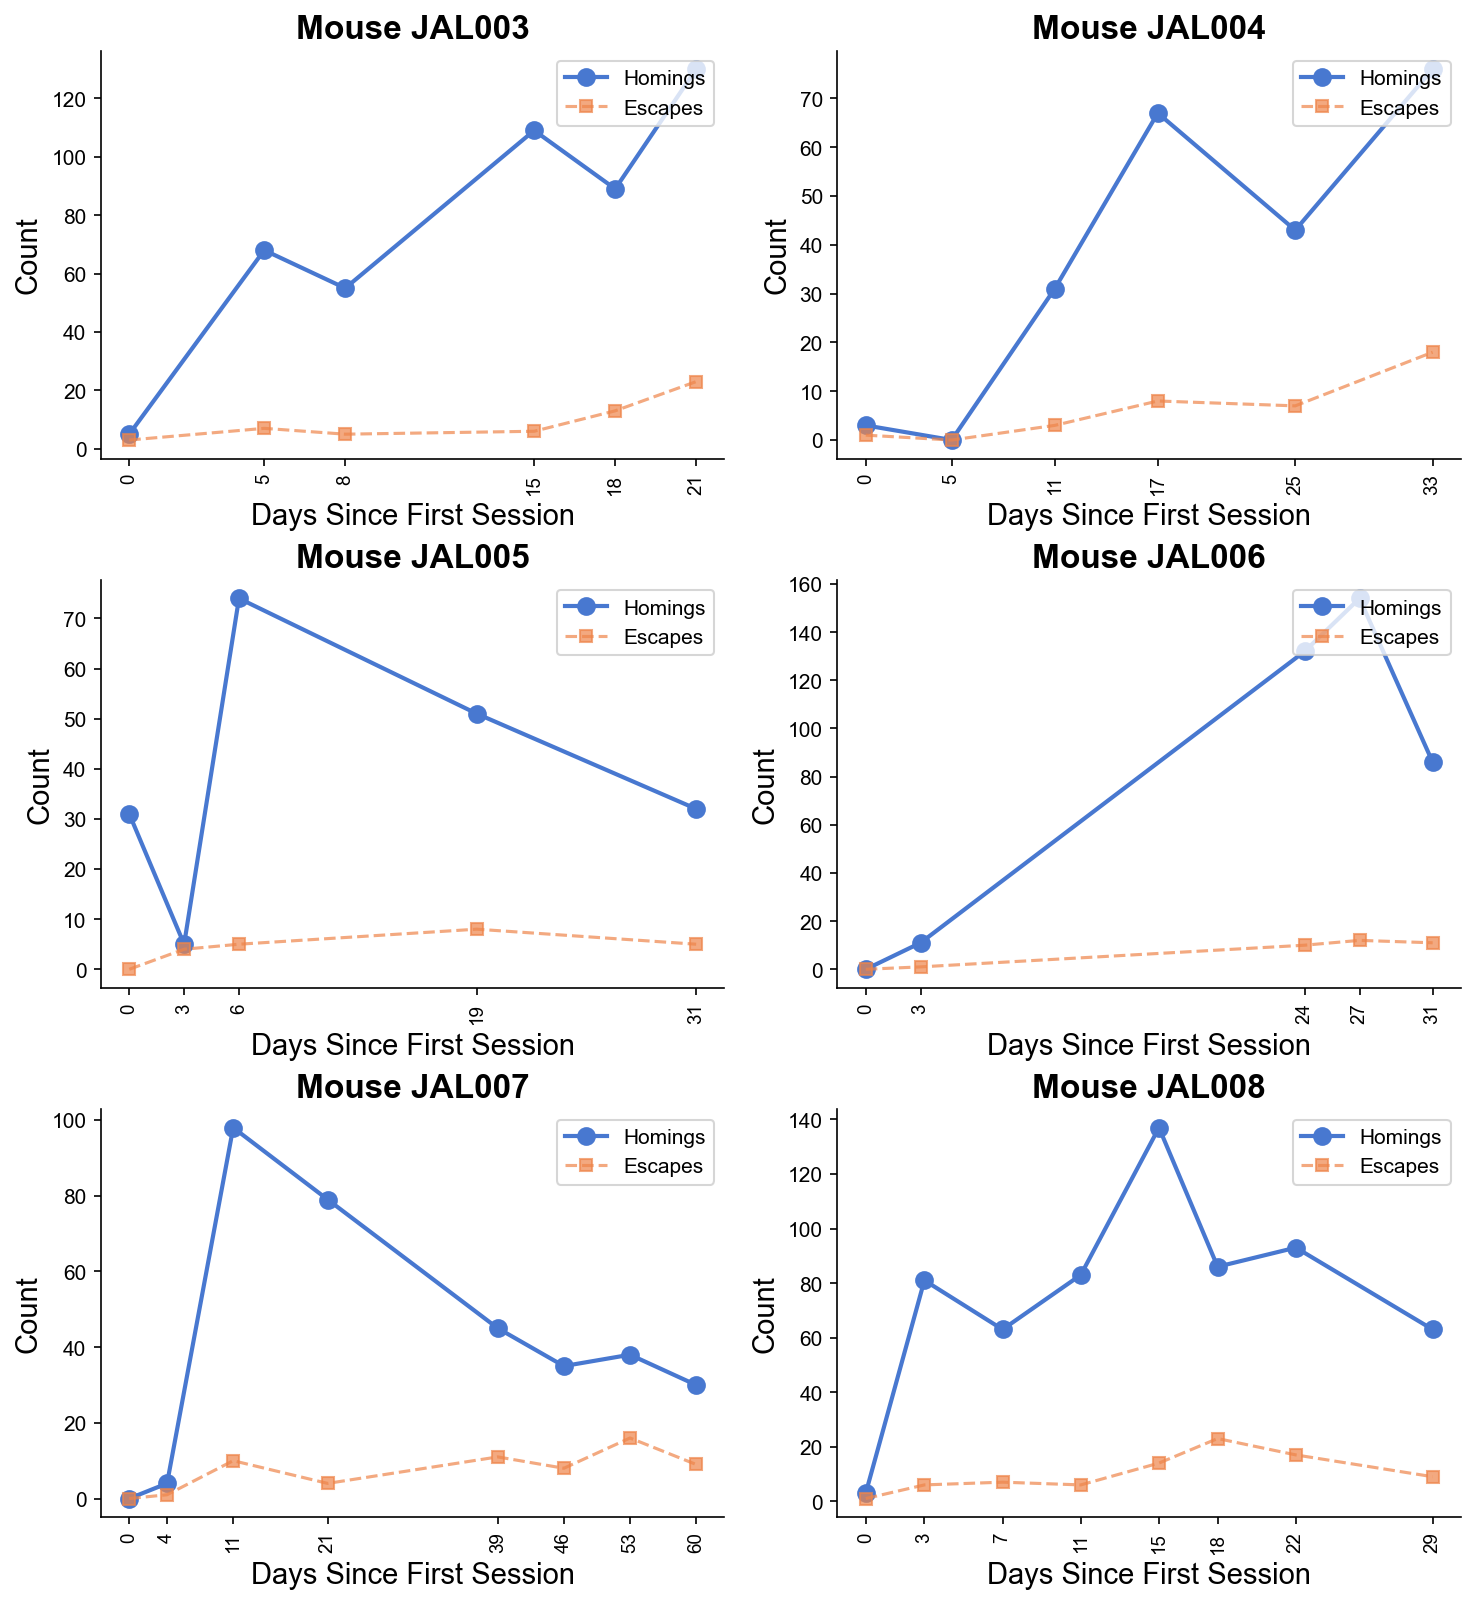

In [7]:
%matplotlib inline
analyze_homings_trend_by_mouse()

# Compare the spatial efficiency between homings and escapes

2025-07-16 15:51:41.230 | INFO     | __main__:compare_spatial_efficiency:8 - Finding all session paths...
2025-07-16 15:51:41.375 | INFO     | __main__:compare_spatial_efficiency:10 - Found 47 session paths


Summary statistics:
Number of homings with efficiency data: 2158
Number of escapes with efficiency data: 309
Mean homing efficiency: 0.953 ± 0.088
Mean escape efficiency: 0.898 ± 0.149


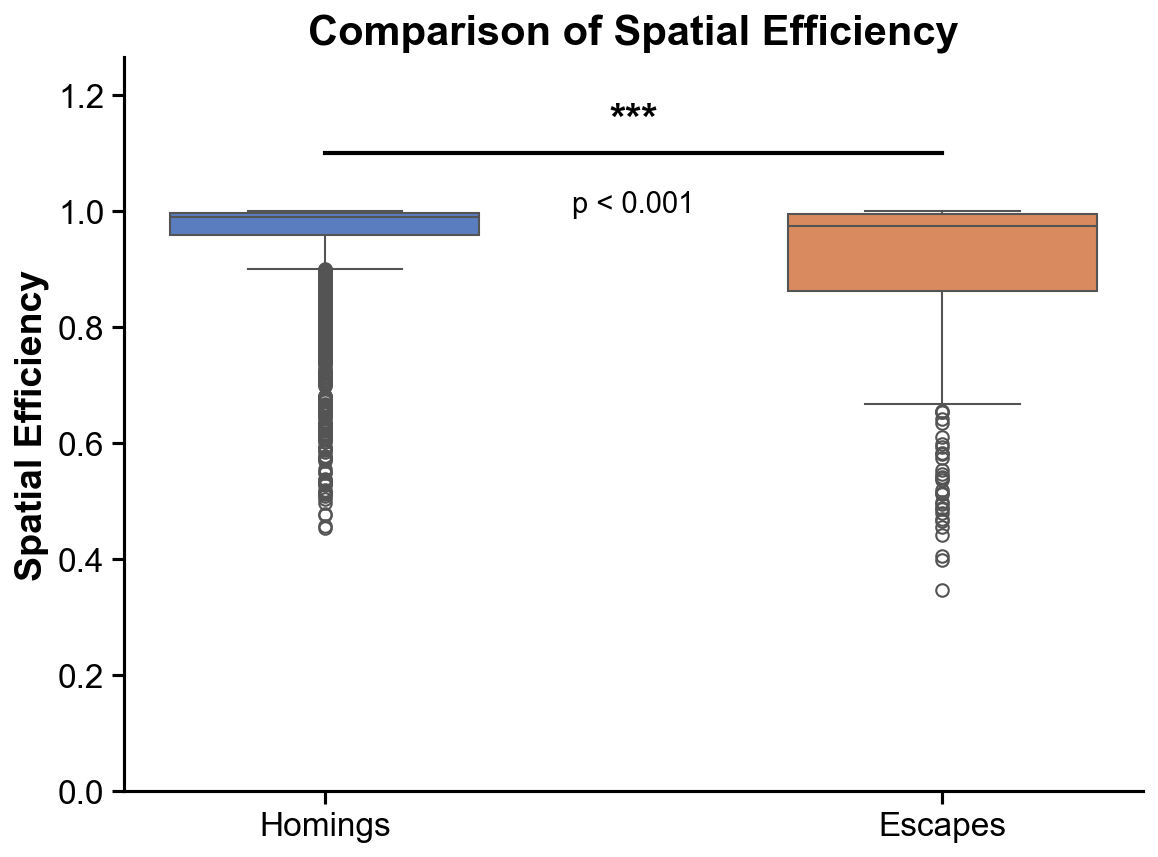

In [9]:
%matplotlib inline
def compare_spatial_efficiency():
    """
    Compare the spatial efficiency of homings vs escapes across all sessions.
    Creates a box plot comparing the distributions and performs statistical analysis.
    """
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Collect spatial efficiency data for homings and escapes
    homings_efficiency = []
    escapes_efficiency = []
    
    # Process each session
    for session_path in session_paths:
        # Load homings object
        homings_obj = load_homings_object(session_path)
        if homings_obj is not None:
            if hasattr(homings_obj, "spatial_efficiency"):
                homings_efficiency.extend(homings_obj.spatial_efficiency)
            elif hasattr(homings_obj, "path_lengths") and hasattr(homings_obj, "shortest_path_lengths"):
                for shortest, actual in zip(homings_obj.shortest_path_lengths, homings_obj.path_lengths):
                    if actual > 0:
                        homings_efficiency.append(shortest / actual)
        # Load escapes object
        escapes_obj = load_escapes_object(session_path)
        if escapes_obj is not None:
            if hasattr(escapes_obj, "spatial_efficiency"):
                escapes_efficiency.extend(escapes_obj.spatial_efficiency)
            elif hasattr(escapes_obj, "path_lengths") and hasattr(escapes_obj, "shortest_path_lengths"):
                for shortest, actual in zip(escapes_obj.shortest_path_lengths, escapes_obj.path_lengths):
                    if actual > 0:
                        escapes_efficiency.append(shortest / actual)
    
    # Check if we have data to analyze
    if not homings_efficiency or not escapes_efficiency:
        logger.error("No spatial efficiency data found for homings and/or escapes")
        print("\nPlease check if your objects have spatial_efficiency, path_lengths, or shortest_path_lengths attributes")
        return None, None
    
    # Create DataFrame for plotting
    data = pd.DataFrame({
        "Behavior Type": ["Homings"] * len(homings_efficiency) + ["Escapes"] * len(escapes_efficiency),
        "Spatial Efficiency": homings_efficiency + escapes_efficiency
    })
    
    # Print summary statistics
    print("Summary statistics:")
    print(f"Number of homings with efficiency data: {len(homings_efficiency)}")
    print(f"Number of escapes with efficiency data: {len(escapes_efficiency)}")
    print(f"Mean homing efficiency: {np.mean(homings_efficiency):.3f} ± {np.std(homings_efficiency):.3f}")
    print(f"Mean escape efficiency: {np.mean(escapes_efficiency):.3f} ± {np.std(escapes_efficiency):.3f}")
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 16,
        "font.family": "Arial",
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "savefig.dpi": 300,
        "figure.dpi": 150
    })
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create box plot only (no swarm/individual points)
    sns.boxplot(x="Behavior Type", y="Spatial Efficiency", data=data, 
                palette=["#4878D0", "#EE854A"], width=0.5, ax=ax)
    
    # Perform statistical test (Mann-Whitney U test for non-parametric comparison)
    from scipy.stats import mannwhitneyu
    stat_result = mannwhitneyu(homings_efficiency, escapes_efficiency)
    p_value = stat_result.pvalue
    
    # Add statistical annotation
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "n.s."
    
    # Calculate position for significance bar
    y_max = max(np.max(homings_efficiency), np.max(escapes_efficiency)) * 1.1
    ax.plot([0, 1], [y_max, y_max], 'k-', linewidth=2)
    ax.text(0.5, y_max * 1.05, significance, ha='center', va='center', fontsize=20, fontweight='bold')
    
    # Add exact p-value
    p_text = f"p = {p_value:.3f}" if p_value >= 0.001 else "p < 0.001"
    ax.text(0.5, y_max * 0.92, p_text, ha='center', va='center', fontsize=14)
    
    # Set axis labels and title
    ax.set_ylabel("Spatial Efficiency", fontweight='bold')
    ax.set_xlabel("")
    ax.set_title("Comparison of Spatial Efficiency", fontweight="bold")
    
    # Set y-axis limits with some padding
    ax.set_ylim(0, y_max * 1.15)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=6)
    
    # Add grid lines for y-axis only
    ax.yaxis.grid(False)
    
    # Tight layout to maximize figure space
    plt.tight_layout()
    
    # Save the figure with high resolution
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "spatial_efficiency_comparison.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "spatial_efficiency_comparison.png"), format='png', bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(save_path, "spatial_efficiency_comparison.pdf"), format='pdf', bbox_inches='tight')
    
    plt.show()
    
    return homings_efficiency, escapes_efficiency

# Run the analysis
homings_eff, escapes_eff = compare_spatial_efficiency()

In [10]:
def compare_spatial_efficiency():
    """
    Compare the spatial efficiency of homings vs escapes across all sessions.
    Creates a box plot comparing the distributions and performs statistical analysis.
    Removes outliers using the IQR method before plotting and statistical testing.
    """
    # Find all session paths
    logger.info("Finding all session paths...")
    session_paths = find_all_sessions()
    logger.info(f"Found {len(session_paths)} session paths")
    
    # Collect spatial efficiency data for homings and escapes
    homings_efficiency = []
    escapes_efficiency = []
    
    # Process each session
    for session_path in session_paths:
        homings_obj = load_homings_object(session_path)
        if homings_obj is not None:
            if hasattr(homings_obj, "spatial_efficiency"):
                homings_efficiency.extend(homings_obj.spatial_efficiency)
            elif hasattr(homings_obj, "path_lengths") and hasattr(homings_obj, "shortest_path_lengths"):
                for shortest, actual in zip(homings_obj.shortest_path_lengths, homings_obj.path_lengths):
                    if actual > 0:
                        homings_efficiency.append(shortest / actual)
        escapes_obj = load_escapes_object(session_path)
        if escapes_obj is not None:
            if hasattr(escapes_obj, "spatial_efficiency"):
                escapes_efficiency.extend(escapes_obj.spatial_efficiency)
            elif hasattr(escapes_obj, "path_lengths") and hasattr(escapes_obj, "shortest_path_lengths"):
                for shortest, actual in zip(escapes_obj.shortest_path_lengths, escapes_obj.path_lengths):
                    if actual > 0:
                        escapes_efficiency.append(shortest / actual)
    
    # Remove outliers using IQR method
    def remove_outliers(data):
        data = np.array(data)
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return data[(data >= lower) & (data <= upper)]
    
    homings_efficiency_clean = remove_outliers(homings_efficiency)
    escapes_efficiency_clean = remove_outliers(escapes_efficiency)
    
    # Check if we have data to analyze
    if len(homings_efficiency_clean) == 0 or len(escapes_efficiency_clean) == 0:
        logger.error("No spatial efficiency data found for homings and/or escapes after outlier removal")
        print("\nPlease check if your objects have spatial_efficiency, path_lengths, or shortest_path_lengths attributes")
        return None, None
    
    # Create DataFrame for plotting
    data = pd.DataFrame({
        "Behavior Type": ["Homings"] * len(homings_efficiency_clean) + ["Escapes"] * len(escapes_efficiency_clean),
        "Spatial Efficiency": np.concatenate([homings_efficiency_clean, escapes_efficiency_clean])
    })
    
    # Print summary statistics
    print("Summary statistics (outliers removed):")
    print(f"Number of homings with efficiency data: {len(homings_efficiency_clean)}")
    print(f"Number of escapes with efficiency data: {len(escapes_efficiency_clean)}")
    print(f"Mean homing efficiency: {np.mean(homings_efficiency_clean):.3f} ± {np.std(homings_efficiency_clean):.3f}")
    print(f"Mean escape efficiency: {np.mean(escapes_efficiency_clean):.3f} ± {np.std(escapes_efficiency_clean):.3f}")
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 16,
        "font.family": "Arial",
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "savefig.dpi": 300,
        "figure.dpi": 150
    })
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(x="Behavior Type", y="Spatial Efficiency", data=data, 
                palette=["#4878D0", "#EE854A"], width=0.5, ax=ax)
    
    # Perform statistical test (Mann-Whitney U test for non-parametric comparison)
    from scipy.stats import mannwhitneyu
    stat_result = mannwhitneyu(homings_efficiency_clean, escapes_efficiency_clean)
    p_value = stat_result.pvalue
    
    # Add statistical annotation
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "n.s."
    
    y_max = max(np.max(homings_efficiency_clean), np.max(escapes_efficiency_clean)) * 1.1
    ax.plot([0, 1], [y_max, y_max], 'k-', linewidth=2)
    ax.text(0.5, y_max * 1.05, significance, ha='center', va='center', fontsize=20, fontweight='bold')
    p_text = f"p = {p_value:.3f}" if p_value >= 0.001 else "p < 0.001"
    ax.text(0.5, y_max * 0.92, p_text, ha='center', va='center', fontsize=14)
    
    ax.set_ylabel("Spatial Efficiency", fontweight='bold')
    ax.set_xlabel("")
    ax.set_title("Comparison of Spatial Efficiency", fontweight="bold")
    ax.set_ylim(0, y_max * 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=6)
    ax.yaxis.grid(False)
    plt.tight_layout()
    
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "spatial_efficiency_comparison.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "spatial_efficiency_comparison.png"), format='png', bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(save_path, "spatial_efficiency_comparison.pdf"), format='pdf', bbox_inches='tight')
    plt.show()
    
    return homings_efficiency_clean, escapes_efficiency_clean

2025-07-16 15:54:55.680 | INFO     | __main__:compare_spatial_efficiency:8 - Finding all session paths...
2025-07-16 15:54:55.824 | INFO     | __main__:compare_spatial_efficiency:10 - Found 47 session paths


Summary statistics (outliers removed):
Number of homings with efficiency data: 1871
Number of escapes with efficiency data: 278
Mean homing efficiency: 0.982 ± 0.021
Mean escape efficiency: 0.939 ± 0.085


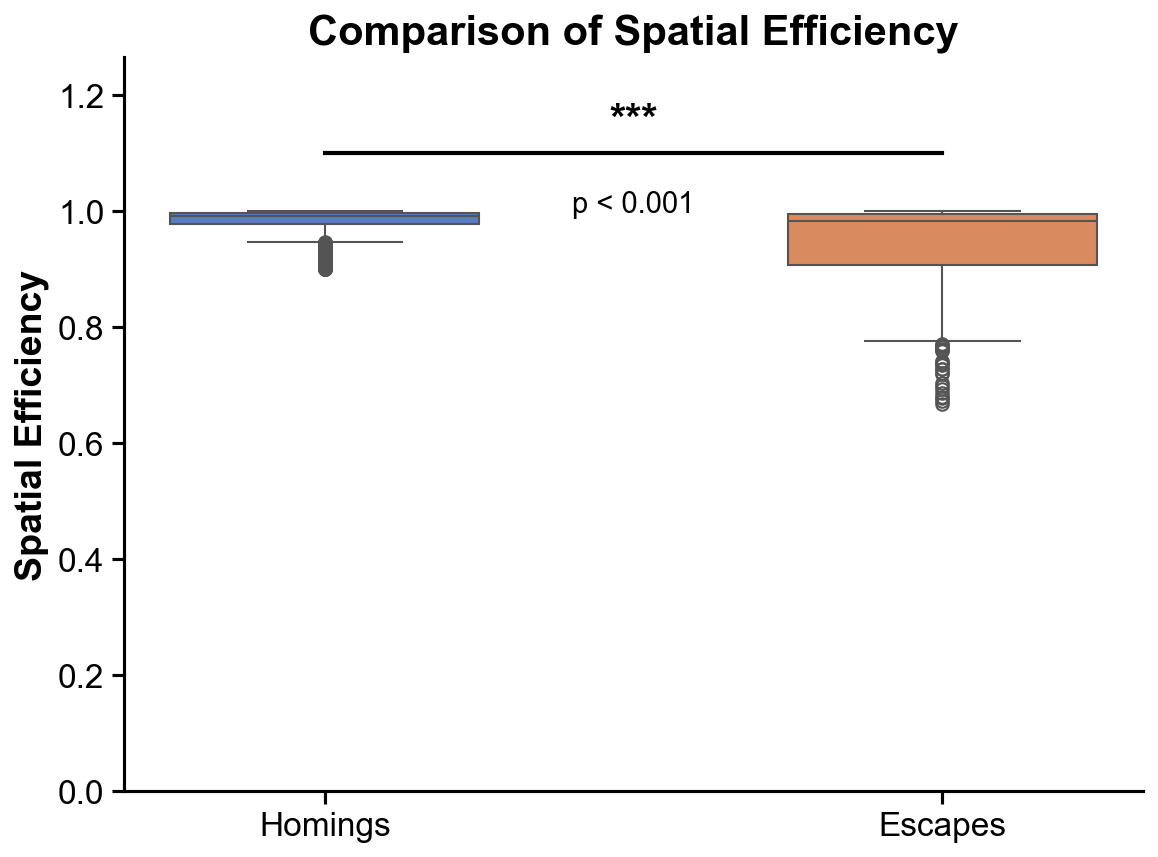

(array([0.99572295, 0.99878704, 0.99078804, ..., 0.95750139, 0.99794093,
        0.96996937]),
 array([0.97091474, 0.99661896, 0.99584826, 0.94405215, 0.96101883,
        0.9660264 , 0.99197296, 0.99857834, 0.9814836 , 0.99389453,
        0.99805785, 0.99902289, 0.9543082 , 0.98789133, 0.8010355 ,
        0.99444631, 0.99679625, 0.80058634, 0.99357701, 0.87480669,
        0.94984108, 0.96743051, 0.95731961, 0.98500796, 0.81906706,
        0.99510964, 0.99733769, 0.80552038, 0.8415452 , 0.993178  ,
        0.98243056, 0.97416886, 0.99340742, 0.98294216, 0.95630752,
        0.76994464, 0.93178643, 0.99894361, 0.99879726, 0.88391665,
        0.99907491, 0.99712584, 0.97395331, 0.98460424, 0.97099593,
        0.85069902, 0.99195867, 0.98649441, 0.98276144, 0.77906373,
        0.79576879, 0.99348535, 0.99154203, 0.80305305, 0.88416616,
        0.99715698, 0.99932907, 0.96691382, 0.99386304, 0.89954217,
        0.86223295, 0.97709916, 0.99787601, 0.87125166, 0.997797  ,
        0.99150125, 0

In [11]:
compare_spatial_efficiency()

# Plot homing trajectory and escapes to show they are similar across conditions for a single mouse

In [ ]:
from behave_analysis.utils.arena_plotting import Arena


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Using homings.homing_condition
Using escapes.escape_condition
Found 23 homings for condition 'shelter_only'
Found 1 escapes for condition 'shelter_only'
Found 69 homings for condition 'barrier_pre_flip'
Found 2 escapes for condition 'barrier_pre_flip'
Found 53 homings for condition 'barrier_post_flip'
Found 4 escapes for condition 'barrier_post_flip'


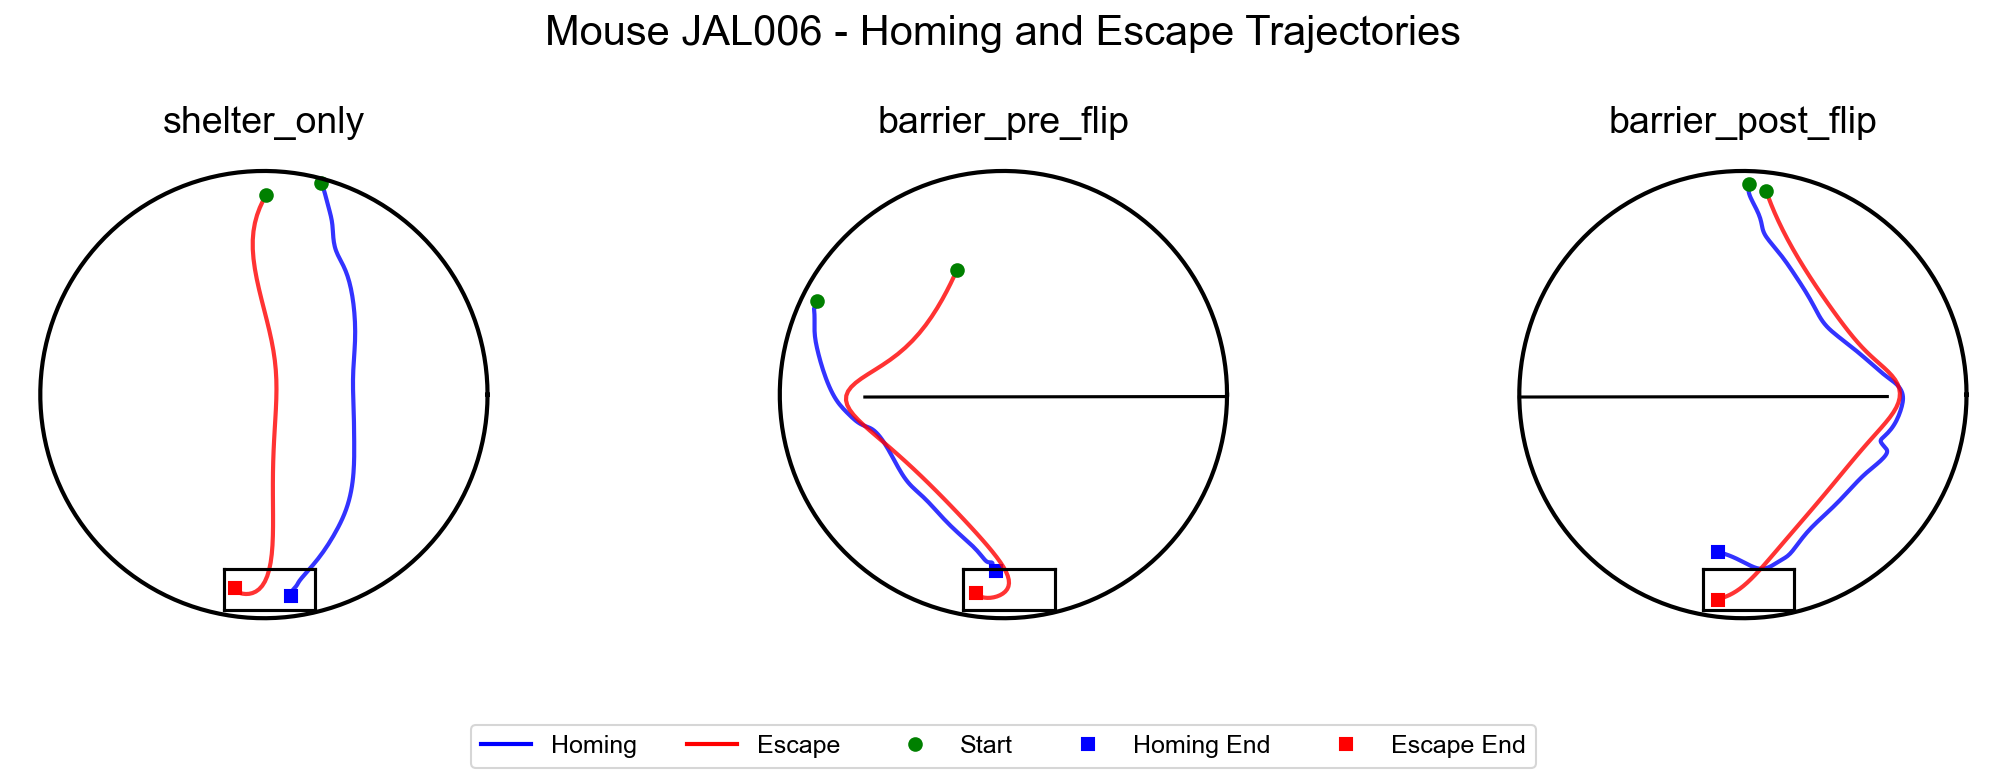

In [32]:
def plot_combined_trajectories_by_condition_improved(homings, escapes, session_path):
    """
    Plot homings and escapes trajectories with custom ordering and improved legend.
    """
    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })
    
    # Try to get tracking data
    tracking_data = None
    if hasattr(homings, 'tracking_data'):
        tracking_data = homings.tracking_data
    elif hasattr(escapes, 'tracking_data'):
        tracking_data = escapes.tracking_data
    else:
        try:
            tracking_data_path = os.path.join(session_path, "processed_data", "fully_processed_tracking_data.pickle")
            with open(tracking_data_path, "rb") as f:
                tracking_data = pickle.load(f)
        except Exception as e:
            print(f"Could not load tracking data: {e}")
            
            # Try alternative paths
            alt_paths = [
                os.path.join(session_path, "processed_data", "tracking_data.pkl"),
                os.path.join(session_path, "processed_data", "tracking.pkl"),
                os.path.join(session_path, "processed_data", "tracking_data.pickle")
            ]
            
            for path in alt_paths:
                try:
                    with open(path, "rb") as f:
                        tracking_data = pickle.load(f)
                        print(f"Successfully loaded tracking data from {path}")
                        break
                except Exception:
                    continue
                    
            if tracking_data is None:
                print("Failed to load tracking data from any location")
                return
    
    # Get conditions from both objects
    homing_conditions = []
    escape_conditions = []
    
    # Check for homing conditions
    if hasattr(homings, "homing_condition"):
        homing_conditions = homings.homing_condition
        print("Using homings.homing_condition")
    elif hasattr(homings, "conditions"):
        homing_conditions = homings.conditions
        print("Using homings.conditions")
    elif hasattr(homings, "trial_conditions"):
        homing_conditions = homings.trial_conditions
        print("Using homings.trial_conditions")
    
    # Check for escape conditions
    if hasattr(escapes, "escape_condition"):
        escape_conditions = escapes.escape_condition
        print("Using escapes.escape_condition")
    elif hasattr(escapes, "conditions"):
        escape_conditions = escapes.conditions
        print("Using escapes.conditions")
    elif hasattr(escapes, "trial_conditions"):
        escape_conditions = escapes.trial_conditions
        print("Using escapes.trial_conditions")
    
    # Combine conditions from both objects
    all_conditions = set(homing_conditions + escape_conditions)
    
    # Custom order and filter out barrier_removed condition
    ordered_conditions = []
    if "shelter_only" in all_conditions:
        ordered_conditions.append("shelter_only")
    if "barrier_pre_flip" in all_conditions:
        ordered_conditions.append("barrier_pre_flip")
    if "barrier_post_flip" in all_conditions:
        ordered_conditions.append("barrier_post_flip")
    
    # Create one row of subplots for each condition
    fig, axes = plt.subplots(1, len(ordered_conditions), figsize=(5*len(ordered_conditions), 5), 
                             sharex=True, sharey=True)
    
    # Handle single condition case
    if len(ordered_conditions) == 1:
        axes = np.array([axes])
    
    # Helper function to get trajectory indices for a condition
    def get_homing_indices_for_condition(condition_name, max_count=1):
        if hasattr(homings, "homing_condition"):
            indices = [i for i, c in enumerate(homings.homing_condition) if c == condition_name]
        elif hasattr(homings, "conditions"):
            indices = [i for i, c in enumerate(homings.conditions) if c == condition_name]
        elif hasattr(homings, "trial_conditions"):
            indices = [i for i, c in enumerate(homings.trial_conditions) if c == condition_name]
        else:
            print(f"No condition attribute found for homings")
            return []
        
        print(f"Found {len(indices)} homings for condition '{condition_name}'")
        return indices[:max_count]
    
    def get_escape_indices_for_condition(condition_name, max_count=1):
        if hasattr(escapes, "escape_condition"):
            indices = [i for i, c in enumerate(escapes.escape_condition) if c == condition_name]
        elif hasattr(escapes, "conditions"):
            indices = [i for i, c in enumerate(escapes.conditions) if c == condition_name]
        elif hasattr(escapes, "trial_conditions"):
            indices = [i for i, c in enumerate(escapes.trial_conditions) if c == condition_name]
        else:
            print(f"No condition attribute found for escapes")
            return []
        
        print(f"Found {len(indices)} escapes for condition '{condition_name}'")
        return indices[:max_count]
    
    # Create empty lines for the legend
    homing_line = plt.Line2D([], [], color='blue', linewidth=2, label='Homing')
    escape_line = plt.Line2D([], [], color='red', linewidth=2, label='Escape')
    start_point = plt.Line2D([], [], color='green', marker='o', linestyle='None', 
                          markersize=6, label='Start')
    homing_end = plt.Line2D([], [], color='blue', marker='s', linestyle='None', 
                         markersize=6, label='Homing End')
    escape_end = plt.Line2D([], [], color='red', marker='s', linestyle='None', 
                         markersize=6, label='Escape End')
    
    # Plot trajectories for each condition
    for col, condition in enumerate(ordered_conditions):
        ax = axes[col]
        
        # Get homings for this condition
        homing_indices = get_homing_indices_for_condition(condition)
        
        # Plot homings
        for i in homing_indices:
            if i < len(homings.onset_frames) and i < len(homings.offset_frames):
                onset = homings.onset_frames[i]
                offset = homings.offset_frames[i]
                
                # Get trajectory coordinates
                x_loc = tracking_data["head_loc"][onset:offset, 0]
                y_loc = tracking_data["head_loc"][onset:offset, 1]
                
                # Plot trajectory with start and end points marked
                ax.plot(x_loc, y_loc, '-', linewidth=2, color='blue', alpha=0.8)
                ax.plot(x_loc[0], y_loc[0], 'o', color='green', markersize=6)  # Start
                ax.plot(x_loc[-1], y_loc[-1], 's', color='blue', markersize=6)  # End
        
        # Get escapes for this condition
        escape_indices = get_escape_indices_for_condition(condition)
        
        # Plot escapes
        for i in escape_indices:
            if i < len(escapes.escape_onset_frames) and i < len(escapes.escape_end_frames):
                onset = escapes.escape_onset_frames[i]
                offset = escapes.escape_end_frames[i]
                
                # Get trajectory coordinates
                x_loc = tracking_data["head_loc"][onset:offset, 0]
                y_loc = tracking_data["head_loc"][onset:offset, 1]
                
                # Plot trajectory with start and end points marked
                ax.plot(x_loc, y_loc, '-', linewidth=2, color='red', alpha=0.8)
                ax.plot(x_loc[0], y_loc[0], 'o', color='green', markersize=6)  # Start
                ax.plot(x_loc[-1], y_loc[-1], 's', color='red', markersize=6)  # End
        
        # Add title and labels
        ax.set_title(f"{condition}")
        ax.set_xlabel("X Position (cm)")
        if col == 0:  # Only add y-axis label to leftmost plot
            ax.set_ylabel("Y Position (cm)")
        ax.set_aspect('equal')
        
        # Draw arena with condition-specific settings
        Arena(ax=ax, 
              shelter_coordinates=tracking_data["shelter_loc"], 
              condition=condition,
              barrier_coordinates=tracking_data["barrier_loc"])
    
    # Add a comprehensive legend to the figure
    fig.legend(
        handles=[homing_line, escape_line, start_point, homing_end, escape_end],
        loc='upper center',
        bbox_to_anchor=(0.5, 0.05),
        ncol=5,
        frameon=True,
        facecolor='white',
        framealpha=0.8
    )
    
    # Add overall title
    mouse_name = os.path.basename(os.path.dirname(session_path))
    fig.suptitle(f"Mouse {mouse_name} - Homing and Escape Trajectories", fontsize=20)
    
    # Adjust layout with extra space at bottom for legend
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    
    # Save figure
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, f"{mouse_name}_combined_trajectory_comparison_improved.eps"), 
                format='eps', bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(save_path, f"{mouse_name}_combined_trajectory_comparison_improved.png"), 
                format='png', bbox_inches='tight', dpi=300)
    
    return fig, axes

# Run the improved function
session_path = r"Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20"
escapes = load_escapes_object(session_path)
homings = load_homings_object(session_path)
fig, axes = plot_combined_trajectories_by_condition_improved(homings, escapes, session_path)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Using homings.homing_condition
Using escapes.escape_condition
Found 23 homings for condition 'shelter_only'
Found 1 escapes for condition 'shelter_only'
Condition shelter_only: Best pair has similarity 0.094
Found 69 homings for condition 'barrier_pre_flip'
Found 2 escapes for condition 'barrier_pre_flip'
Condition barrier_pre_flip: Best pair has similarity 0.115
Found 53 homings for condition 'barrier_post_flip'
Found 4 escapes for condition 'barrier_post_flip'
Condition barrier_post_flip: Best pair has similarity 0.173


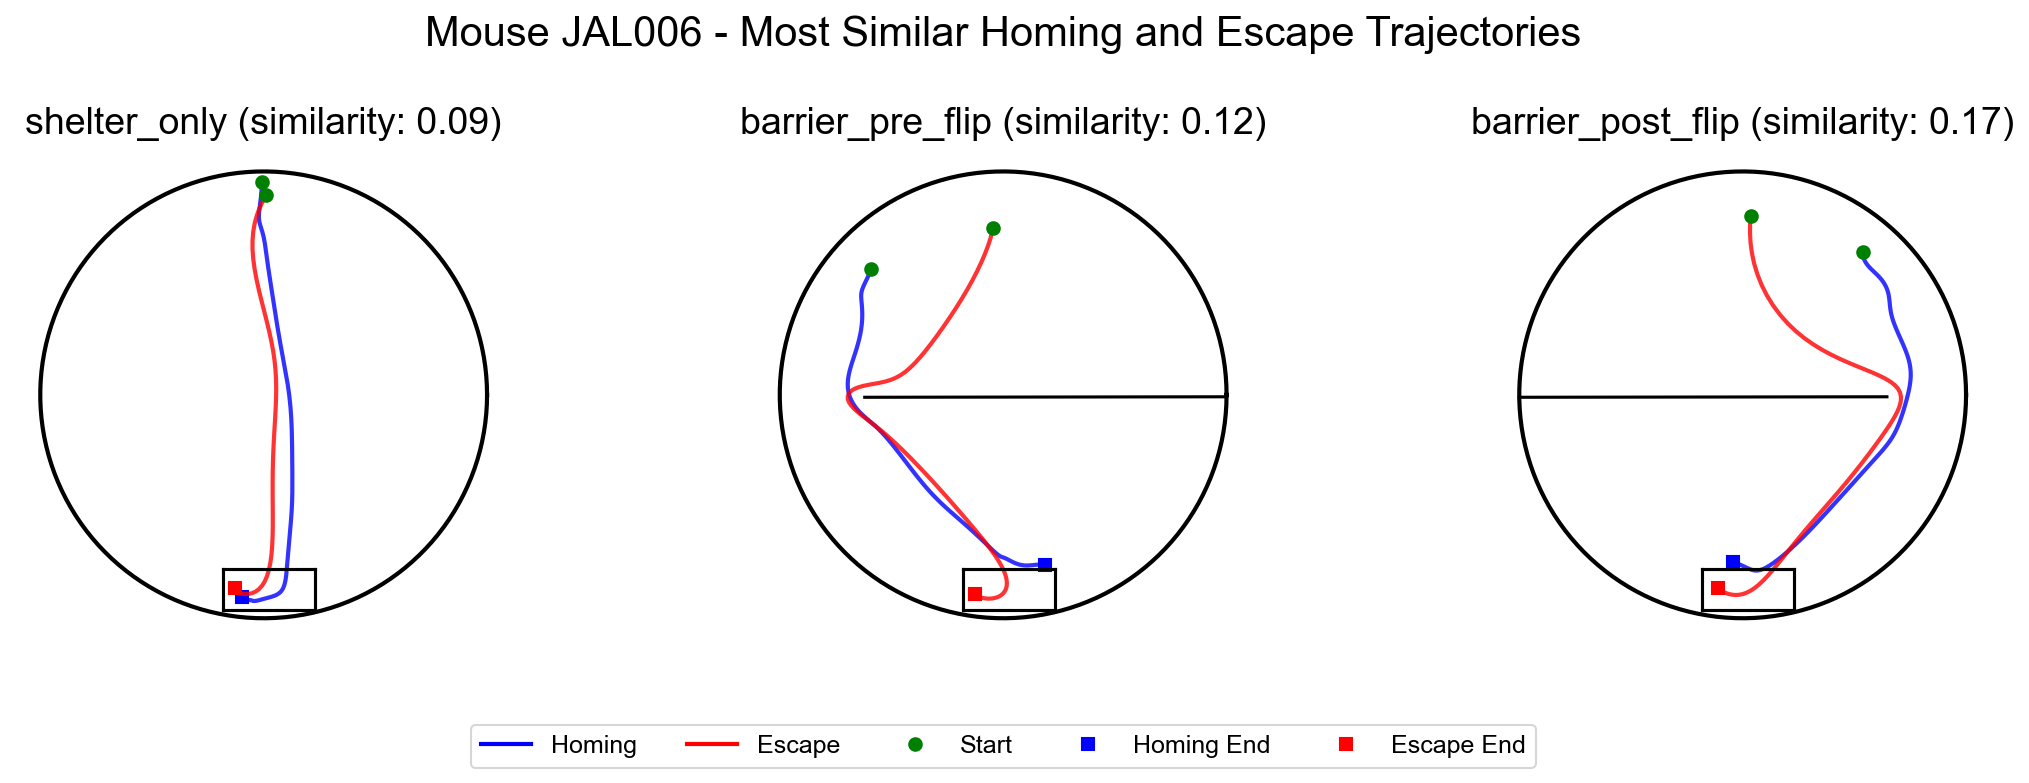

In [33]:
def plot_combined_trajectories_by_condition_improved(homings, escapes, session_path):
    """
    Plot homings and escapes trajectories with custom ordering and improved legend.
    For each condition, find the most spatially similar homing-escape pair.
    """
    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })
    
    # Try to get tracking data
    tracking_data = None
    if hasattr(homings, 'tracking_data'):
        tracking_data = homings.tracking_data
    elif hasattr(escapes, 'tracking_data'):
        tracking_data = escapes.tracking_data
    else:
        try:
            tracking_data_path = os.path.join(session_path, "processed_data", "fully_processed_tracking_data.pickle")
            with open(tracking_data_path, "rb") as f:
                tracking_data = pickle.load(f)
        except Exception as e:
            print(f"Could not load tracking data: {e}")
            
            # Try alternative paths
            alt_paths = [
                os.path.join(session_path, "processed_data", "tracking_data.pkl"),
                os.path.join(session_path, "processed_data", "tracking.pkl"),
                os.path.join(session_path, "processed_data", "tracking_data.pickle")
            ]
            
            for path in alt_paths:
                try:
                    with open(path, "rb") as f:
                        tracking_data = pickle.load(f)
                        print(f"Successfully loaded tracking data from {path}")
                        break
                except Exception:
                    continue
                    
            if tracking_data is None:
                print("Failed to load tracking data from any location")
                return
    
    # Get conditions from both objects
    homing_conditions = []
    escape_conditions = []
    
    # Check for homing conditions
    if hasattr(homings, "homing_condition"):
        homing_conditions = homings.homing_condition
        print("Using homings.homing_condition")
    elif hasattr(homings, "conditions"):
        homing_conditions = homings.conditions
        print("Using homings.conditions")
    elif hasattr(homings, "trial_conditions"):
        homing_conditions = homings.trial_conditions
        print("Using homings.trial_conditions")
    
    # Check for escape conditions
    if hasattr(escapes, "escape_condition"):
        escape_conditions = escapes.escape_condition
        print("Using escapes.escape_condition")
    elif hasattr(escapes, "conditions"):
        escape_conditions = escapes.conditions
        print("Using escapes.conditions")
    elif hasattr(escapes, "trial_conditions"):
        escape_conditions = escapes.trial_conditions
        print("Using escapes.trial_conditions")
    
    # Combine conditions from both objects
    all_conditions = set(homing_conditions + escape_conditions)
    
    # Custom order and filter out barrier_removed condition
    ordered_conditions = []
    if "shelter_only" in all_conditions:
        ordered_conditions.append("shelter_only")
    if "barrier_pre_flip" in all_conditions:
        ordered_conditions.append("barrier_pre_flip")
    if "barrier_post_flip" in all_conditions:
        ordered_conditions.append("barrier_post_flip")
    
    # Create one row of subplots for each condition
    fig, axes = plt.subplots(1, len(ordered_conditions), figsize=(5*len(ordered_conditions), 5), 
                             sharex=True, sharey=True)
    
    # Handle single condition case
    if len(ordered_conditions) == 1:
        axes = np.array([axes])
    
    # Helper function to get trajectory indices for a condition
    def get_homing_indices_for_condition(condition_name):
        if hasattr(homings, "homing_condition"):
            indices = [i for i, c in enumerate(homings.homing_condition) if c == condition_name]
        elif hasattr(homings, "conditions"):
            indices = [i for i, c in enumerate(homings.conditions) if c == condition_name]
        elif hasattr(homings, "trial_conditions"):
            indices = [i for i, c in enumerate(homings.trial_conditions) if c == condition_name]
        else:
            print(f"No condition attribute found for homings")
            return []
        
        print(f"Found {len(indices)} homings for condition '{condition_name}'")
        return indices
    
    def get_escape_indices_for_condition(condition_name):
        if hasattr(escapes, "escape_condition"):
            indices = [i for i, c in enumerate(escapes.escape_condition) if c == condition_name]
        elif hasattr(escapes, "conditions"):
            indices = [i for i, c in enumerate(escapes.conditions) if c == condition_name]
        elif hasattr(escapes, "trial_conditions"):
            indices = [i for i, c in enumerate(escapes.trial_conditions) if c == condition_name]
        else:
            print(f"No condition attribute found for escapes")
            return []
        
        print(f"Found {len(indices)} escapes for condition '{condition_name}'")
        return indices
    
    # Function to convert trajectory points to a grid
    def trajectory_to_grid(x_points, y_points, grid_size=50):
        # Get arena bounds
        x_min, x_max = np.min(x_points), np.max(x_points)
        y_min, y_max = np.min(y_points), np.max(y_points)
        
        # Add a small buffer
        x_range = x_max - x_min + 1e-5
        y_range = y_max - y_min + 1e-5
        
        # Discretize into grid
        x_grid = np.floor((x_points - x_min) / x_range * grid_size).astype(int)
        y_grid = np.floor((y_points - y_min) / y_range * grid_size).astype(int)
        
        # Create set of occupied grid cells
        occupied_cells = set(zip(x_grid, y_grid))
        return occupied_cells
    
    # Function to calculate Jaccard similarity (intersection over union)
    def calculate_similarity(traj1_grid, traj2_grid):
        intersection = len(traj1_grid.intersection(traj2_grid))
        union = len(traj1_grid.union(traj2_grid))
        if union == 0:
            return 0
        return intersection / union
    
    # Function to find most similar homing-escape pair
    def find_most_similar_pair(condition):
        homing_indices = get_homing_indices_for_condition(condition)
        escape_indices = get_escape_indices_for_condition(condition)
        
        if not homing_indices or not escape_indices:
            return None, None, 0
            
        best_similarity = -1
        best_homing_idx = None
        best_escape_idx = None
        
        # Calculate trajectory for each homing
        homing_trajectories = []
        for h_idx in homing_indices:
            if h_idx < len(homings.onset_frames) and h_idx < len(homings.offset_frames):
                h_onset = homings.onset_frames[h_idx]
                h_offset = homings.offset_frames[h_idx]
                h_x = tracking_data["head_loc"][h_onset:h_offset, 0]
                h_y = tracking_data["head_loc"][h_onset:h_offset, 1]
                h_grid = trajectory_to_grid(h_x, h_y)
                homing_trajectories.append((h_idx, h_grid))
        
        # Calculate trajectory for each escape
        escape_trajectories = []
        for e_idx in escape_indices:
            if e_idx < len(escapes.escape_onset_frames) and e_idx < len(escapes.escape_end_frames):
                e_onset = escapes.escape_onset_frames[e_idx]
                e_offset = escapes.escape_end_frames[e_idx]
                e_x = tracking_data["head_loc"][e_onset:e_offset, 0]
                e_y = tracking_data["head_loc"][e_onset:e_offset, 1]
                e_grid = trajectory_to_grid(e_x, e_y)
                escape_trajectories.append((e_idx, e_grid))
        
        # Compare all homing-escape pairs
        for h_idx, h_grid in homing_trajectories:
            for e_idx, e_grid in escape_trajectories:
                similarity = calculate_similarity(h_grid, e_grid)
                
                if similarity > best_similarity:
                    best_similarity = similarity
                    best_homing_idx = h_idx
                    best_escape_idx = e_idx
        
        print(f"Condition {condition}: Best pair has similarity {best_similarity:.3f}")
        return best_homing_idx, best_escape_idx, best_similarity
    
    # Create empty lines for the legend
    homing_line = plt.Line2D([], [], color='blue', linewidth=2, label='Homing')
    escape_line = plt.Line2D([], [], color='red', linewidth=2, label='Escape')
    start_point = plt.Line2D([], [], color='green', marker='o', linestyle='None', 
                          markersize=6, label='Start')
    homing_end = plt.Line2D([], [], color='blue', marker='s', linestyle='None', 
                         markersize=6, label='Homing End')
    escape_end = plt.Line2D([], [], color='red', marker='s', linestyle='None', 
                         markersize=6, label='Escape End')
    
    # Plot trajectories for each condition
    for col, condition in enumerate(ordered_conditions):
        ax = axes[col]
        
        # Find the most similar homing-escape pair for this condition
        best_homing_idx, best_escape_idx, similarity = find_most_similar_pair(condition)
        
        # Plot the best homing trajectory
        if best_homing_idx is not None:
            onset = homings.onset_frames[best_homing_idx]
            offset = homings.offset_frames[best_homing_idx]
            
            # Get trajectory coordinates
            x_loc = tracking_data["head_loc"][onset:offset, 0]
            y_loc = tracking_data["head_loc"][onset:offset, 1]
            
            # Plot trajectory with start and end points marked
            ax.plot(x_loc, y_loc, '-', linewidth=2, color='blue', alpha=0.8)
            ax.plot(x_loc[0], y_loc[0], 'o', color='green', markersize=6)  # Start
            ax.plot(x_loc[-1], y_loc[-1], 's', color='blue', markersize=6)  # End
        
        # Plot the best escape trajectory
        if best_escape_idx is not None:
            onset = escapes.escape_onset_frames[best_escape_idx]
            offset = escapes.escape_end_frames[best_escape_idx]
            
            # Get trajectory coordinates
            x_loc = tracking_data["head_loc"][onset:offset, 0]
            y_loc = tracking_data["head_loc"][onset:offset, 1]
            
            # Plot trajectory with start and end points marked
            ax.plot(x_loc, y_loc, '-', linewidth=2, color='red', alpha=0.8)
            ax.plot(x_loc[0], y_loc[0], 'o', color='green', markersize=6)  # Start
            ax.plot(x_loc[-1], y_loc[-1], 's', color='red', markersize=6)  # End
        
        # Add title and labels with similarity score
        similarity_text = f" (similarity: {similarity:.2f})" if best_homing_idx is not None and best_escape_idx is not None else ""
        ax.set_title(f"{condition}{similarity_text}")
        ax.set_xlabel("X Position (cm)")
        if col == 0:  # Only add y-axis label to leftmost plot
            ax.set_ylabel("Y Position (cm)")
        ax.set_aspect('equal')
        
        # Draw arena with condition-specific settings
        Arena(ax=ax, 
              shelter_coordinates=tracking_data["shelter_loc"], 
              condition=condition,
              barrier_coordinates=tracking_data["barrier_loc"])
    
    # Add a comprehensive legend to the figure
    fig.legend(
        handles=[homing_line, escape_line, start_point, homing_end, escape_end],
        loc='upper center',
        bbox_to_anchor=(0.5, 0.05),
        ncol=5,
        frameon=True,
        facecolor='white',
        framealpha=0.8
    )
    
    # Add overall title
    mouse_name = os.path.basename(os.path.dirname(session_path))
    fig.suptitle(f"Mouse {mouse_name} - Most Similar Homing and Escape Trajectories", fontsize=20)
    
    # Adjust layout with extra space at bottom for legend
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    
    # Save figure
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, f"{mouse_name}_combined_trajectory_similarity.eps"), 
                format='eps', bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(save_path, f"{mouse_name}_combined_trajectory_similarity.png"), 
                format='png', bbox_inches='tight', dpi=300)
    
    return fig, axes

# Run the improved function
session_path = r"Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20"
escapes = load_escapes_object(session_path)
homings = load_homings_object(session_path)
fig, axes = plot_combined_trajectories_by_condition_improved(homings, escapes, session_path)


Generated trajectory pairs:
1. ID: barrier_post_flip_h1_e3, Similarity: 0.050
2. ID: barrier_post_flip_h3_e1, Similarity: 0.022
3. ID: barrier_post_flip_h1_e2, Similarity: 0.021
4. ID: barrier_post_flip_h1_e1, Similarity: 0.016
5. ID: barrier_post_flip_h3_e3, Similarity: 0.015
6. ID: barrier_post_flip_h3_e2, Similarity: 0.015
7. ID: barrier_post_flip_h2_e1, Similarity: 0.000
8. ID: barrier_post_flip_h2_e2, Similarity: 0.000
9. ID: barrier_post_flip_h2_e3, Similarity: 0.000
10. ID: barrier_pre_flip_h1_e2, Similarity: 0.042
11. ID: barrier_pre_flip_h3_e1, Similarity: 0.036
12. ID: barrier_pre_flip_h2_e2, Similarity: 0.029
13. ID: barrier_pre_flip_h1_e1, Similarity: 0.023
14. ID: barrier_pre_flip_h3_e2, Similarity: 0.022
15. ID: barrier_pre_flip_h2_e1, Similarity: 0.000
16. ID: shelter_only_h2_e1, Similarity: 0.094
17. ID: shelter_only_h1_e1, Similarity: 0.037
18. ID: shelter_only_h3_e1, Similarity: 0.008


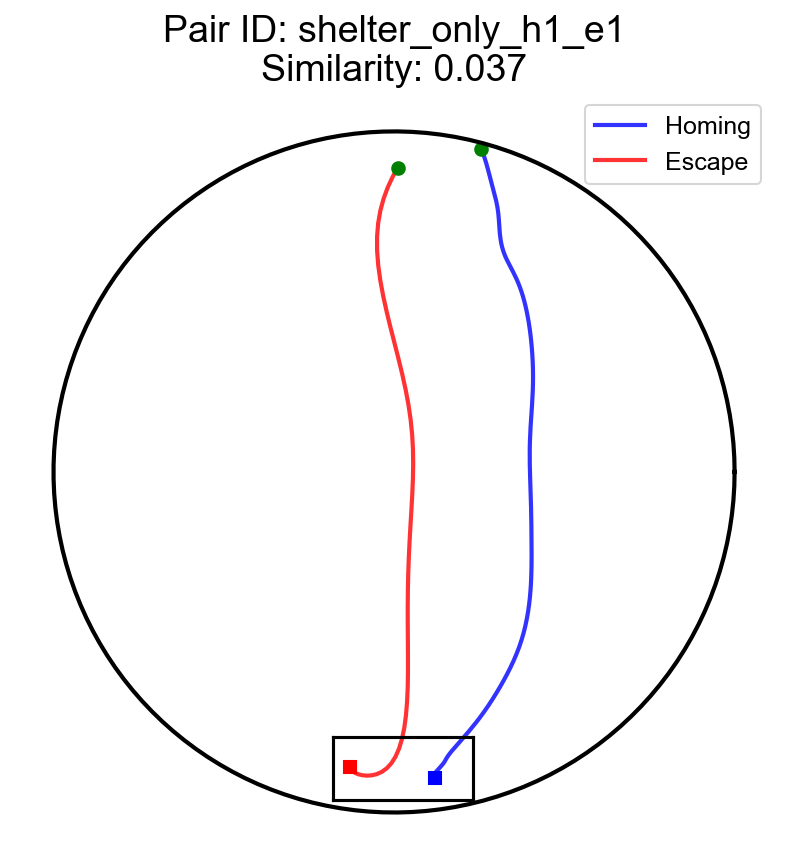

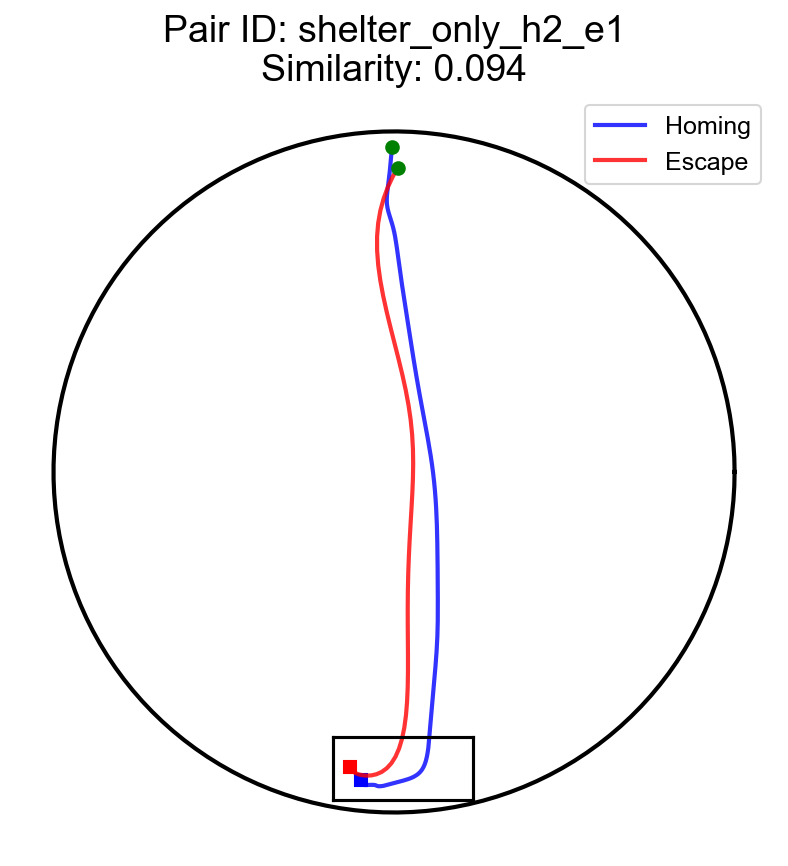

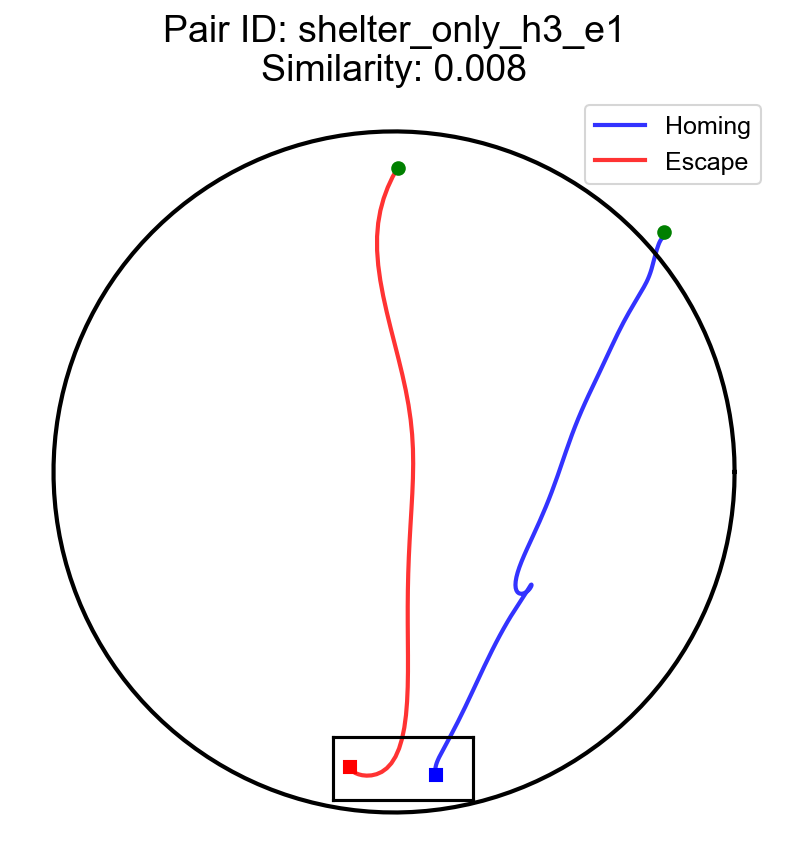

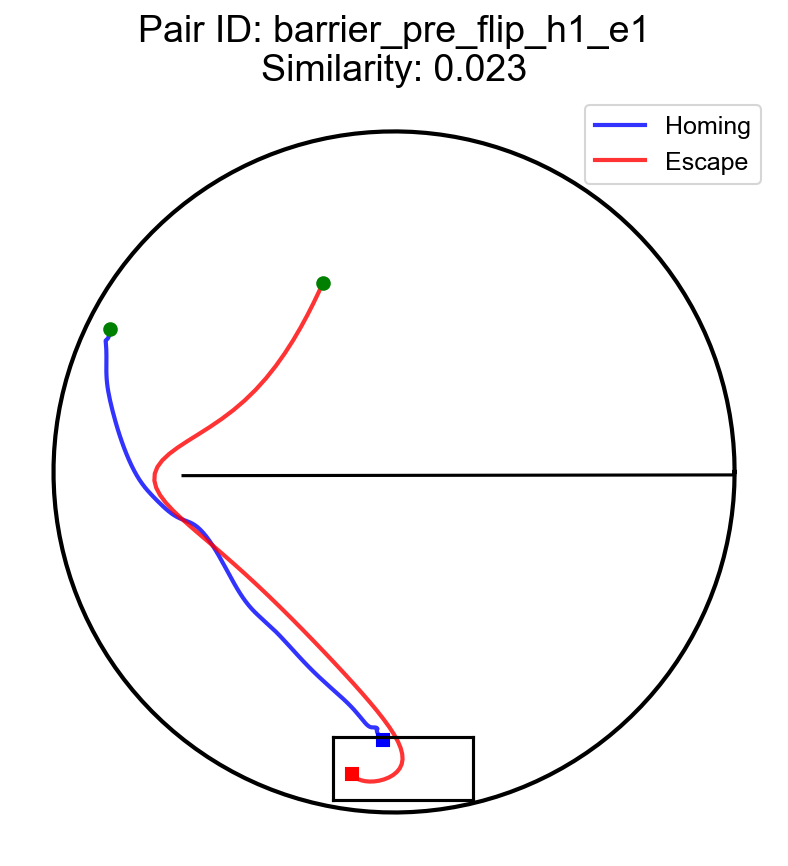

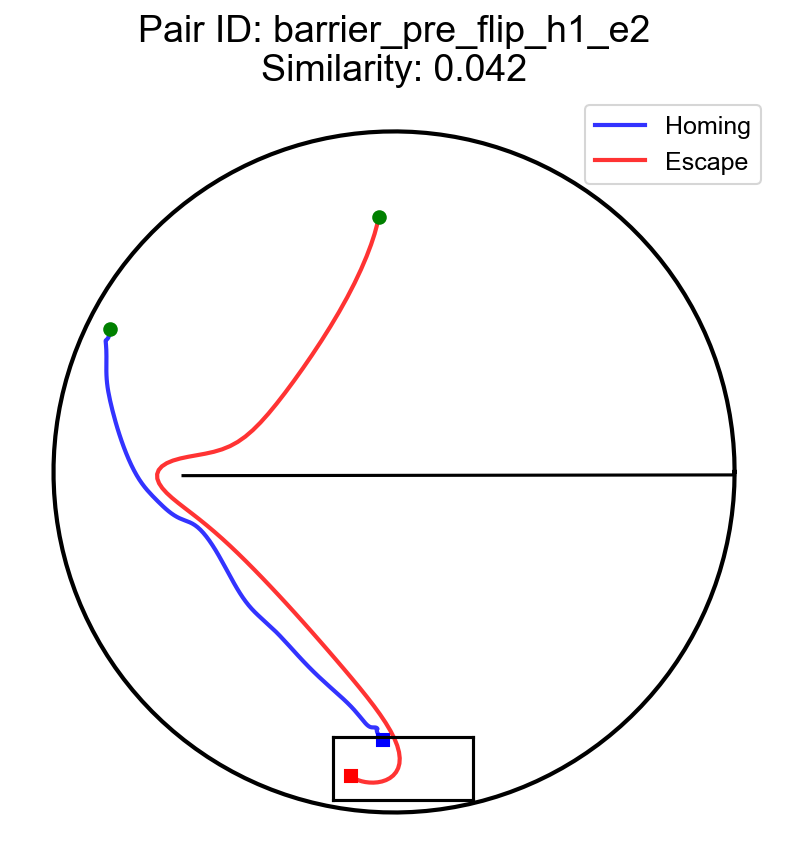

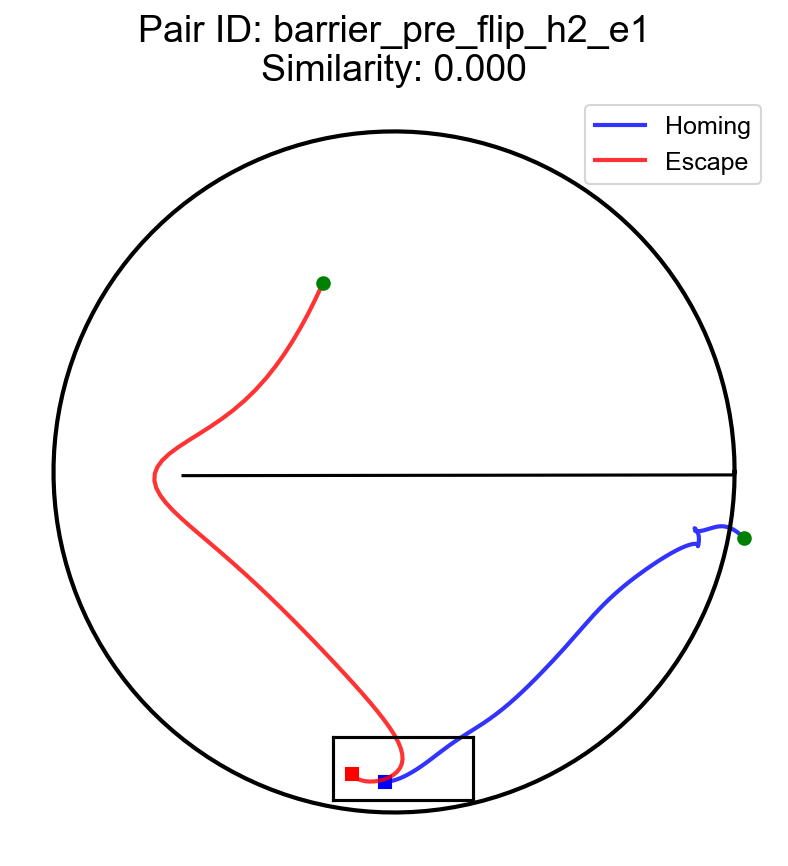

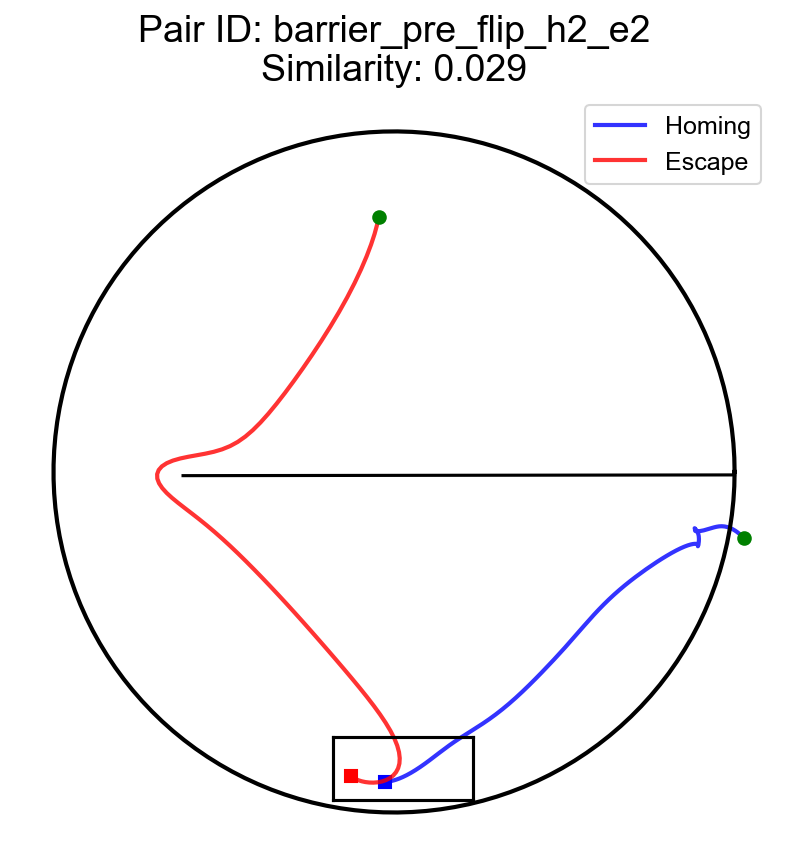

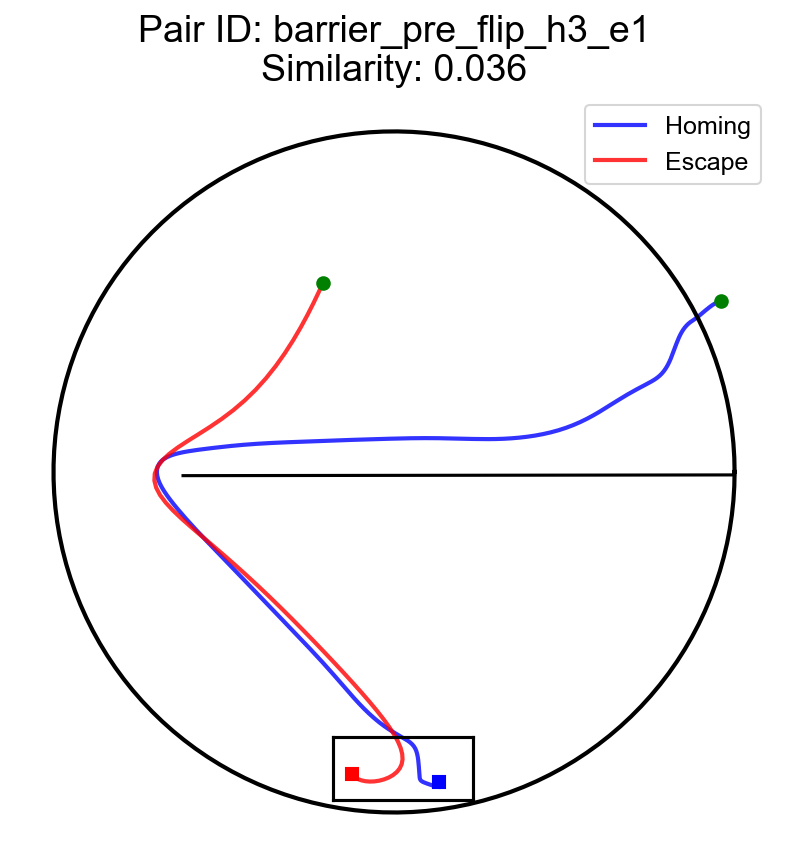

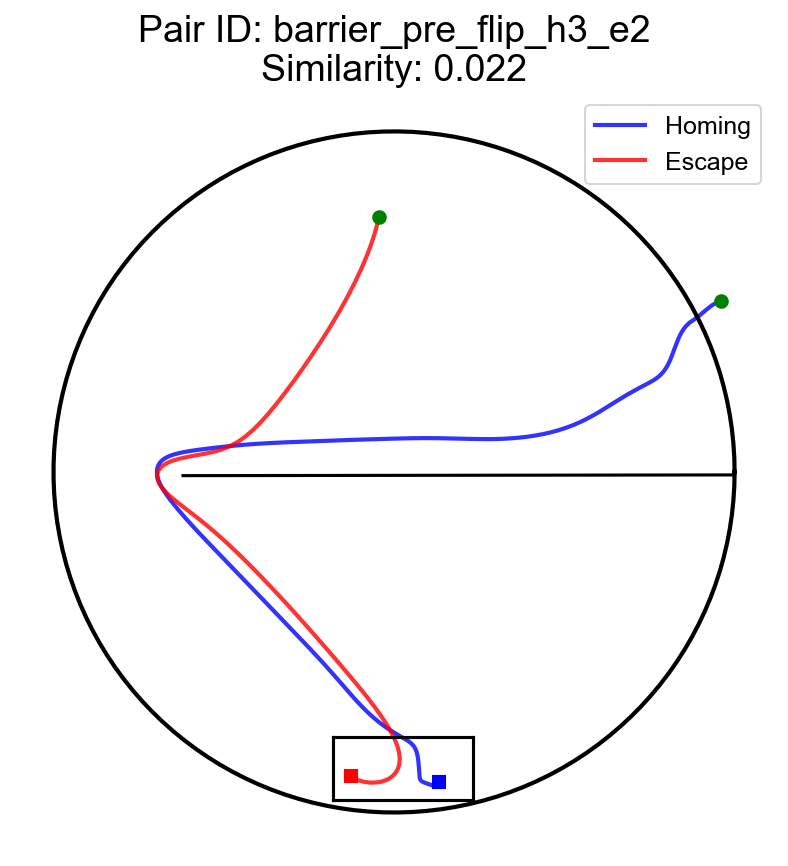

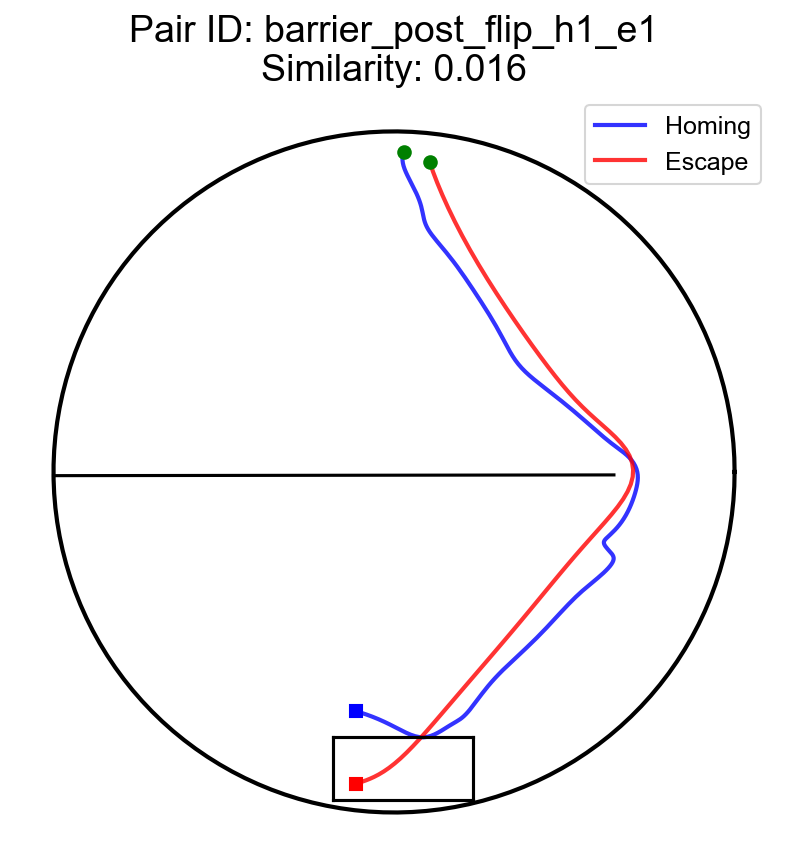

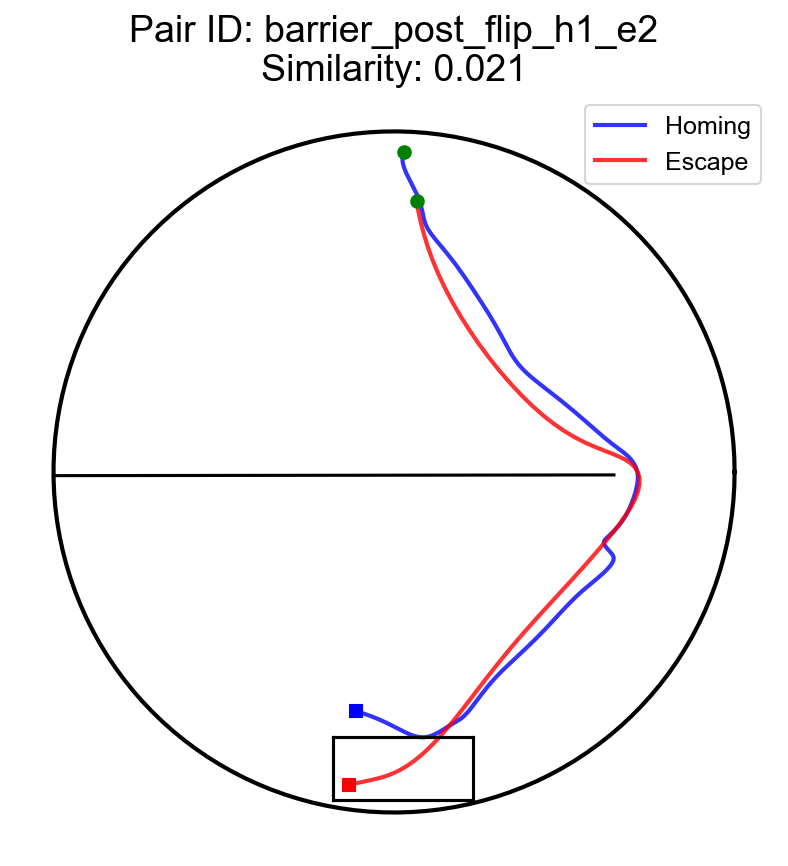

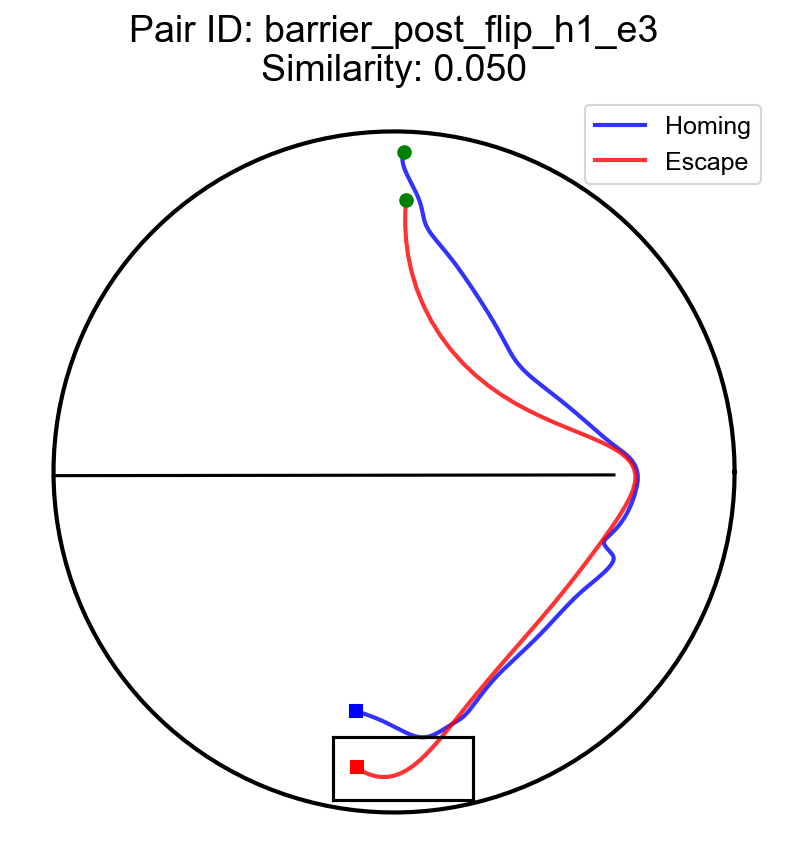

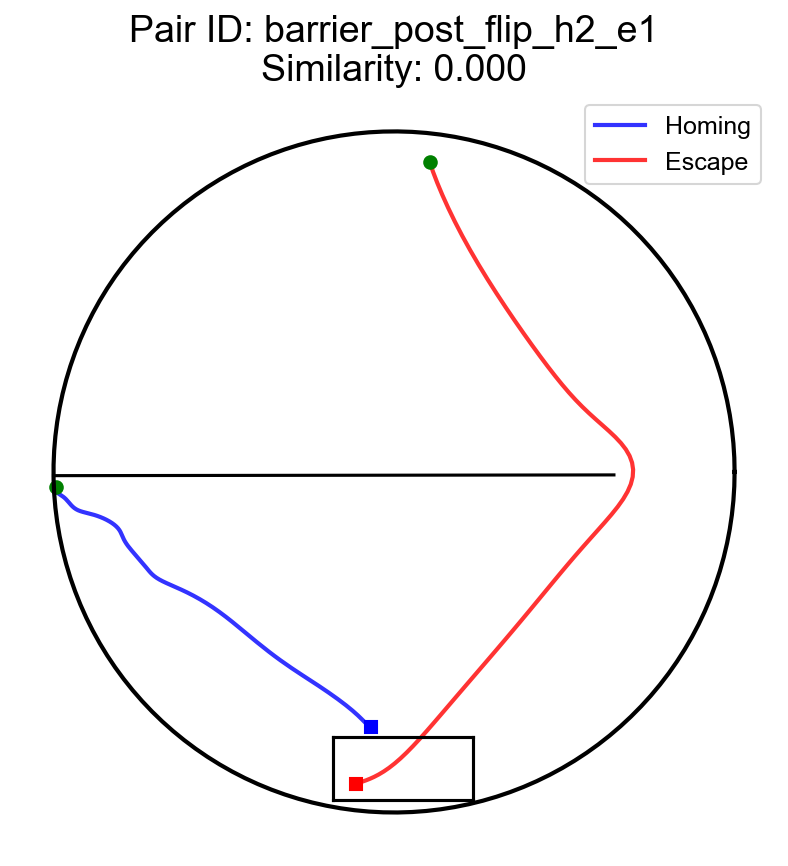

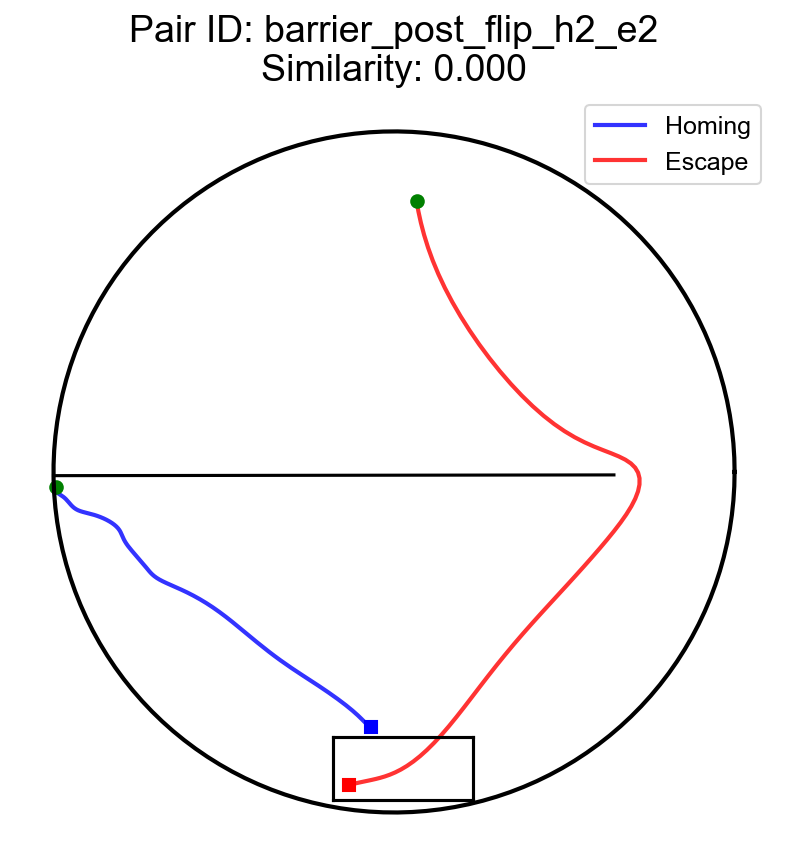

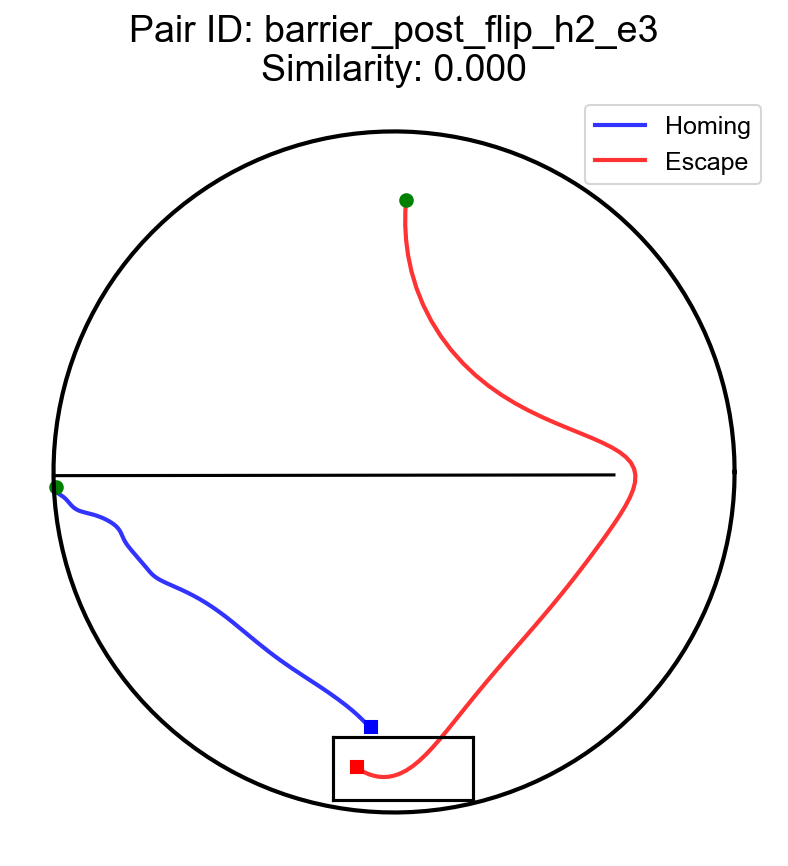

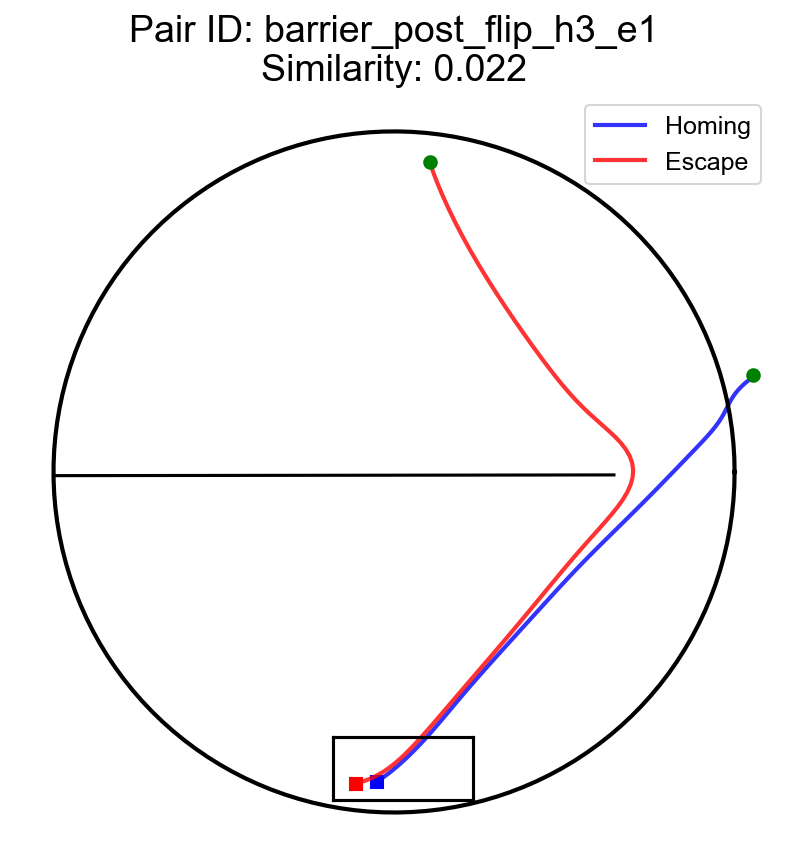

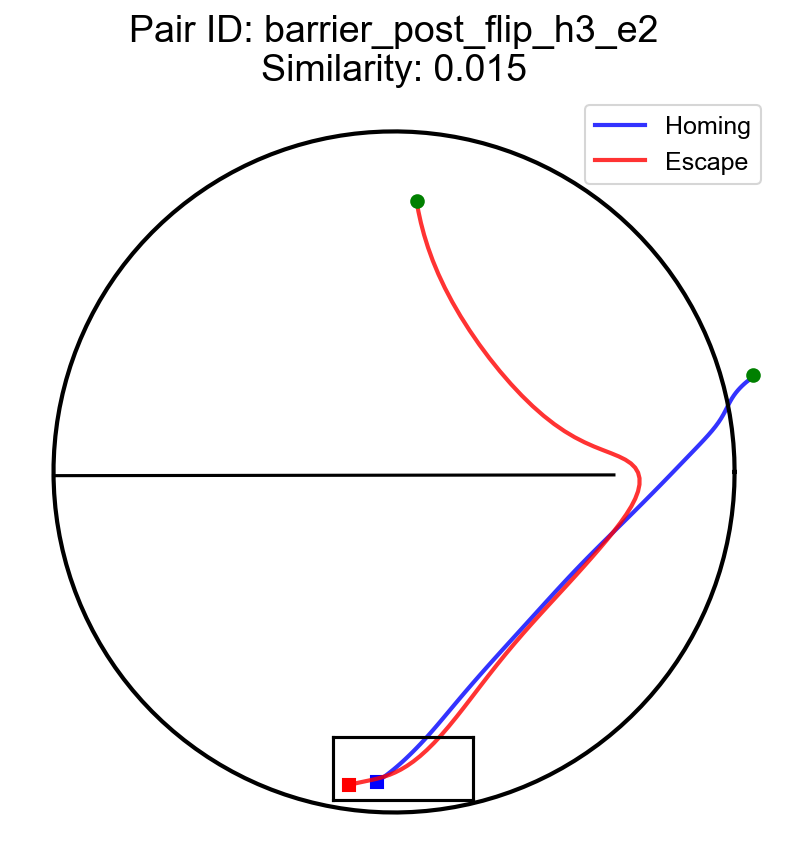

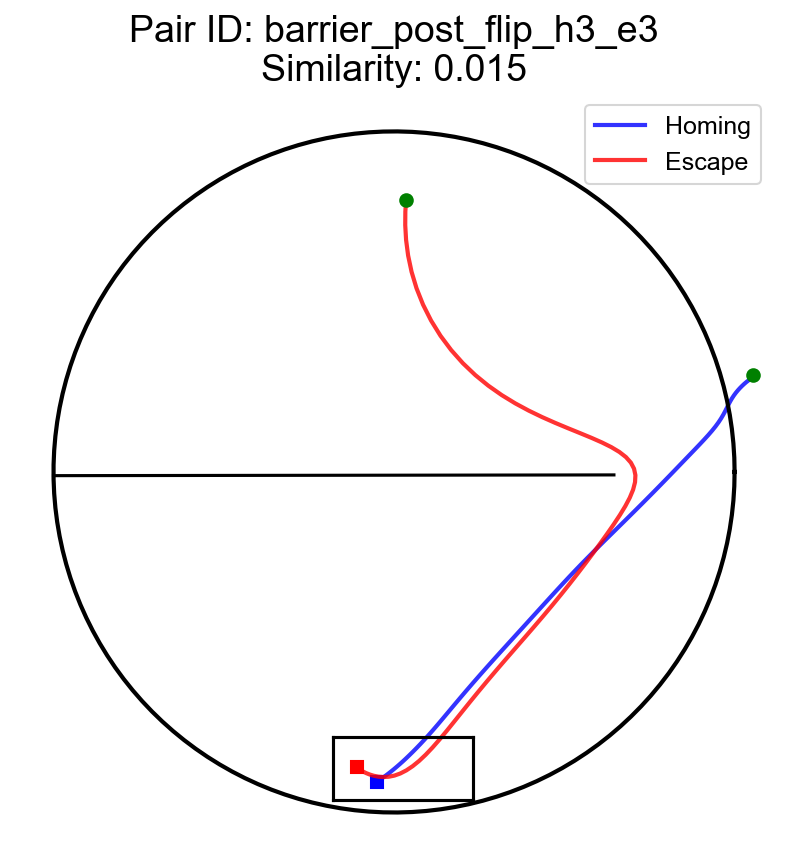

In [35]:
def plot_multiple_trajectory_pairs(homings, escapes, session_path):
    """
    Generate multiple plots showing different homing-escape trajectory pairs.
    Each pair is assigned a unique ID.
    """
    # Configure plot parameters
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })
    
    # Try to get tracking data
    tracking_data = None
    if hasattr(homings, 'tracking_data'):
        tracking_data = homings.tracking_data
    elif hasattr(escapes, 'tracking_data'):
        tracking_data = escapes.tracking_data
    else:
        try:
            tracking_data_path = os.path.join(session_path, "processed_data", "fully_processed_tracking_data.pickle")
            with open(tracking_data_path, "rb") as f:
                tracking_data = pickle.load(f)
        except Exception as e:
            print(f"Could not load tracking data: {e}")
            
            # Try alternative paths
            alt_paths = [
                os.path.join(session_path, "processed_data", "tracking_data.pkl"),
                os.path.join(session_path, "processed_data", "tracking.pkl"),
                os.path.join(session_path, "processed_data", "tracking_data.pickle")
            ]
            
            for path in alt_paths:
                try:
                    with open(path, "rb") as f:
                        tracking_data = pickle.load(f)
                        print(f"Successfully loaded tracking data from {path}")
                        break
                except Exception:
                    continue
                    
            if tracking_data is None:
                print("Failed to load tracking data from any location")
                return
    
    # Get conditions from both objects
    homing_conditions = []
    escape_conditions = []
    
    # Check for homing conditions
    if hasattr(homings, "homing_condition"):
        homing_conditions = homings.homing_condition
    elif hasattr(homings, "conditions"):
        homing_conditions = homings.conditions
    elif hasattr(homings, "trial_conditions"):
        homing_conditions = homings.trial_conditions
    
    # Check for escape conditions
    if hasattr(escapes, "escape_condition"):
        escape_conditions = escapes.escape_condition
    elif hasattr(escapes, "conditions"):
        escape_conditions = escapes.conditions
    elif hasattr(escapes, "trial_conditions"):
        escape_conditions = escapes.trial_conditions
    
    # Combine conditions from both objects
    all_conditions = set(homing_conditions + escape_conditions)
    
    # Custom order and filter out barrier_removed condition
    ordered_conditions = []
    if "shelter_only" in all_conditions:
        ordered_conditions.append("shelter_only")
    if "barrier_pre_flip" in all_conditions:
        ordered_conditions.append("barrier_pre_flip")
    if "barrier_post_flip" in all_conditions:
        ordered_conditions.append("barrier_post_flip")
    
    # Helper function to get trajectory indices for a condition
    def get_homing_indices_for_condition(condition_name, max_count=3):
        if hasattr(homings, "homing_condition"):
            indices = [i for i, c in enumerate(homings.homing_condition) if c == condition_name]
        elif hasattr(homings, "conditions"):
            indices = [i for i, c in enumerate(homings.conditions) if c == condition_name]
        elif hasattr(homings, "trial_conditions"):
            indices = [i for i, c in enumerate(homings.trial_conditions) if c == condition_name]
        else:
            return []
        
        return indices[:min(max_count, len(indices))]
    
    def get_escape_indices_for_condition(condition_name, max_count=3):
        if hasattr(escapes, "escape_condition"):
            indices = [i for i, c in enumerate(escapes.escape_condition) if c == condition_name]
        elif hasattr(escapes, "conditions"):
            indices = [i for i, c in enumerate(escapes.conditions) if c == condition_name]
        elif hasattr(escapes, "trial_conditions"):
            indices = [i for i, c in enumerate(escapes.trial_conditions) if c == condition_name]
        else:
            return []
        
        return indices[:min(max_count, len(indices))]
    
    # Function to calculate Jaccard similarity
    def calculate_similarity(h_idx, e_idx):
        if h_idx >= len(homings.onset_frames) or h_idx >= len(homings.offset_frames) or \
           e_idx >= len(escapes.escape_onset_frames) or e_idx >= len(escapes.escape_end_frames):
            return 0
            
        h_onset = homings.onset_frames[h_idx]
        h_offset = homings.offset_frames[h_idx]
        h_x = tracking_data["head_loc"][h_onset:h_offset, 0]
        h_y = tracking_data["head_loc"][h_onset:h_offset, 1]
        
        e_onset = escapes.escape_onset_frames[e_idx]
        e_offset = escapes.escape_end_frames[e_idx]
        e_x = tracking_data["head_loc"][e_onset:e_offset, 0]
        e_y = tracking_data["head_loc"][e_onset:e_offset, 1]
        
        # Create grid for each trajectory
        def trajectory_to_grid(x_points, y_points, grid_size=50):
            x_min, x_max = np.min(x_points), np.max(x_points)
            y_min, y_max = np.min(y_points), np.max(y_points)
            x_range = x_max - x_min + 1e-5
            y_range = y_max - y_min + 1e-5
            x_grid = np.floor((x_points - x_min) / x_range * grid_size).astype(int)
            y_grid = np.floor((y_points - y_min) / y_range * grid_size).astype(int)
            return set(zip(x_grid, y_grid))
            
        h_grid = trajectory_to_grid(h_x, h_y)
        e_grid = trajectory_to_grid(e_x, e_y)
        
        # Calculate Jaccard similarity
        intersection = len(h_grid.intersection(e_grid))
        union = len(h_grid.union(e_grid))
        return intersection / union if union > 0 else 0
    
    # Generate separate plots for each condition and pair combination
    pair_info = []
    mouse_name = os.path.basename(os.path.dirname(session_path))
    save_path = os.path.join("Z:", "Laurence", "thesis", "figures", "homings", "pairs")
    os.makedirs(save_path, exist_ok=True)
    
    for condition in ordered_conditions:
        homing_indices = get_homing_indices_for_condition(condition)
        escape_indices = get_escape_indices_for_condition(condition)
        
        if not homing_indices or not escape_indices:
            continue
        
        for h_idx in homing_indices:
            for e_idx in escape_indices:
                # Create unique ID for this pair
                pair_id = f"{condition}_h{homing_indices.index(h_idx) + 1}_e{escape_indices.index(e_idx) + 1}"
                
                # Calculate similarity
                similarity = calculate_similarity(h_idx, e_idx)
                
                # Create figure
                fig, ax = plt.subplots(figsize=(6, 6))
                
                # Plot homing trajectory
                if h_idx < len(homings.onset_frames) and h_idx < len(homings.offset_frames):
                    onset = homings.onset_frames[h_idx]
                    offset = homings.offset_frames[h_idx]
                    x_loc = tracking_data["head_loc"][onset:offset, 0]
                    y_loc = tracking_data["head_loc"][onset:offset, 1]
                    ax.plot(x_loc, y_loc, '-', linewidth=2, color='blue', alpha=0.8, label='Homing')
                    ax.plot(x_loc[0], y_loc[0], 'o', color='green', markersize=6)  # Start
                    ax.plot(x_loc[-1], y_loc[-1], 's', color='blue', markersize=6)  # End
                
                # Plot escape trajectory
                if e_idx < len(escapes.escape_onset_frames) and e_idx < len(escapes.escape_end_frames):
                    onset = escapes.escape_onset_frames[e_idx]
                    offset = escapes.escape_end_frames[e_idx]
                    x_loc = tracking_data["head_loc"][onset:offset, 0]
                    y_loc = tracking_data["head_loc"][onset:offset, 1]
                    ax.plot(x_loc, y_loc, '-', linewidth=2, color='red', alpha=0.8, label='Escape')
                    ax.plot(x_loc[0], y_loc[0], 'o', color='green', markersize=6)  # Start
                    ax.plot(x_loc[-1], y_loc[-1], 's', color='red', markersize=6)  # End
                
                # Add labels and arena
                ax.set_title(f"Pair ID: {pair_id}\nSimilarity: {similarity:.3f}")
                ax.set_xlabel("X Position (cm)")
                ax.set_ylabel("Y Position (cm)")
                ax.set_aspect('equal')
                
                # Draw arena
                Arena(ax=ax, 
                      shelter_coordinates=tracking_data["shelter_loc"], 
                      condition=condition,
                      barrier_coordinates=tracking_data["barrier_loc"])
                
                # Add legend
                ax.legend(loc='upper right')
                
                # Save figure
                plt.tight_layout()
                plt.savefig(os.path.join(save_path, f"{mouse_name}_{pair_id}.png"), 
                            dpi=300, bbox_inches='tight')
                #plt.close(fig)
                
                # Store information about this pair
                pair_info.append({
                    'pair_id': pair_id,
                    'condition': condition,
                    'homing_idx': h_idx,
                    'escape_idx': e_idx,
                    'similarity': similarity,
                    'filename': f"{mouse_name}_{pair_id}.png"
                })
    
    # Create a summary figure showing all the pairs sorted by similarity
    pair_info.sort(key=lambda x: (x['condition'], -x['similarity']))
    
    # Print summary of available pairs
    print("\nGenerated trajectory pairs:")
    for i, pair in enumerate(pair_info):
        print(f"{i+1}. ID: {pair['pair_id']}, Similarity: {pair['similarity']:.3f}")
    
    return pair_info

# Run the function
session_path = r"Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20"
escapes = load_escapes_object(session_path)
homings = load_homings_object(session_path)
pair_info = plot_multiple_trajectory_pairs(homings, escapes, session_path)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Found 23 homings for condition 'shelter_only'
Found 1 escapes for condition 'shelter_only'
Found 69 homings for condition 'barrier_pre_flip'
Found 2 escapes for condition 'barrier_pre_flip'
Found 53 homings for condition 'barrier_post_flip'
Found 4 escapes for condition 'barrier_post_flip'


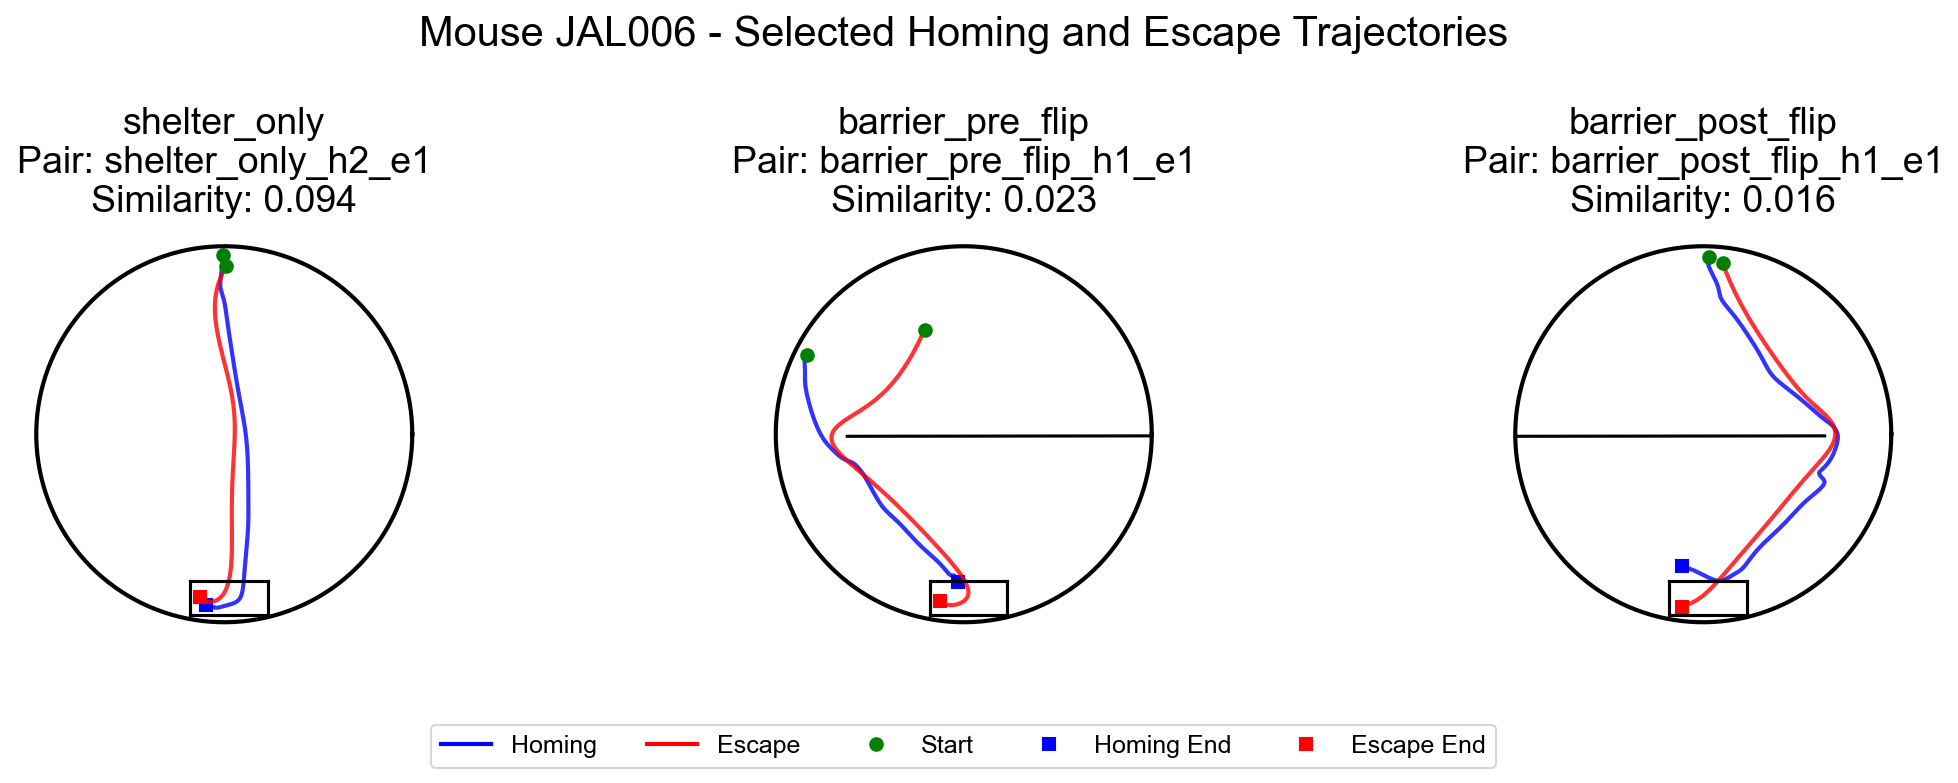

In [36]:
def plot_combined_trajectories_with_selected_pairs(homings, escapes, session_path, selected_pairs):
    """
    Plot homings and escapes trajectories using specific pairs for each condition.
    
    Parameters:
    -----------
    homings : object
        Homings object containing trajectory data
    escapes : object
        Escapes object containing trajectory data
    session_path : str
        Path to the session directory
    selected_pairs : dict
        Dictionary mapping condition names to tuples of (homing_number, escape_number)
        where numbers are 1-indexed position in the list of trajectories for that condition
    """
    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })
    
    # Try to get tracking data
    tracking_data = None
    if hasattr(homings, 'tracking_data'):
        tracking_data = homings.tracking_data
    elif hasattr(escapes, 'tracking_data'):
        tracking_data = escapes.tracking_data
    else:
        try:
            tracking_data_path = os.path.join(session_path, "processed_data", "fully_processed_tracking_data.pickle")
            with open(tracking_data_path, "rb") as f:
                tracking_data = pickle.load(f)
        except Exception as e:
            print(f"Could not load tracking data: {e}")
            
            # Try alternative paths
            alt_paths = [
                os.path.join(session_path, "processed_data", "tracking_data.pkl"),
                os.path.join(session_path, "processed_data", "tracking.pkl"),
                os.path.join(session_path, "processed_data", "tracking_data.pickle")
            ]
            
            for path in alt_paths:
                try:
                    with open(path, "rb") as f:
                        tracking_data = pickle.load(f)
                        print(f"Successfully loaded tracking data from {path}")
                        break
                except Exception:
                    continue
                    
            if tracking_data is None:
                print("Failed to load tracking data from any location")
                return
    
    # Get conditions from both objects
    homing_conditions = []
    escape_conditions = []
    
    # Check for homing conditions
    if hasattr(homings, "homing_condition"):
        homing_conditions = homings.homing_condition
    elif hasattr(homings, "conditions"):
        homing_conditions = homings.conditions
    elif hasattr(homings, "trial_conditions"):
        homing_conditions = homings.trial_conditions
    
    # Check for escape conditions
    if hasattr(escapes, "escape_condition"):
        escape_conditions = escapes.escape_condition
    elif hasattr(escapes, "conditions"):
        escape_conditions = escapes.conditions
    elif hasattr(escapes, "trial_conditions"):
        escape_conditions = escapes.trial_conditions
    
    # Organize conditions to match the order in selected_pairs
    ordered_conditions = list(selected_pairs.keys())
    
    # Create one row of subplots for each condition
    fig, axes = plt.subplots(1, len(ordered_conditions), figsize=(5*len(ordered_conditions), 5), 
                             sharex=True, sharey=True)
    
    # Handle single condition case
    if len(ordered_conditions) == 1:
        axes = np.array([axes])
    
    # Helper function to get trajectory indices for a condition
    def get_homing_indices_for_condition(condition_name):
        if hasattr(homings, "homing_condition"):
            indices = [i for i, c in enumerate(homings.homing_condition) if c == condition_name]
        elif hasattr(homings, "conditions"):
            indices = [i for i, c in enumerate(homings.conditions) if c == condition_name]
        elif hasattr(homings, "trial_conditions"):
            indices = [i for i, c in enumerate(homings.trial_conditions) if c == condition_name]
        else:
            print(f"No condition attribute found for homings")
            return []
        
        print(f"Found {len(indices)} homings for condition '{condition_name}'")
        return indices
    
    def get_escape_indices_for_condition(condition_name):
        if hasattr(escapes, "escape_condition"):
            indices = [i for i, c in enumerate(escapes.escape_condition) if c == condition_name]
        elif hasattr(escapes, "conditions"):
            indices = [i for i, c in enumerate(escapes.conditions) if c == condition_name]
        elif hasattr(escapes, "trial_conditions"):
            indices = [i for i, c in enumerate(escapes.trial_conditions) if c == condition_name]
        else:
            print(f"No condition attribute found for escapes")
            return []
        
        print(f"Found {len(indices)} escapes for condition '{condition_name}'")
        return indices
    
    # Function to calculate Jaccard similarity (for display purposes)
    def calculate_similarity(h_idx, e_idx):
        if h_idx >= len(homings.onset_frames) or h_idx >= len(homings.offset_frames) or \
           e_idx >= len(escapes.escape_onset_frames) or e_idx >= len(escapes.escape_end_frames):
            return 0
            
        h_onset = homings.onset_frames[h_idx]
        h_offset = homings.offset_frames[h_idx]
        h_x = tracking_data["head_loc"][h_onset:h_offset, 0]
        h_y = tracking_data["head_loc"][h_onset:h_offset, 1]
        
        e_onset = escapes.escape_onset_frames[e_idx]
        e_offset = escapes.escape_end_frames[e_idx]
        e_x = tracking_data["head_loc"][e_onset:e_offset, 0]
        e_y = tracking_data["head_loc"][e_onset:e_offset, 1]
        
        # Create grid for each trajectory
        def trajectory_to_grid(x_points, y_points, grid_size=50):
            x_min, x_max = np.min(x_points), np.max(x_points)
            y_min, y_max = np.min(y_points), np.max(y_points)
            x_range = x_max - x_min + 1e-5
            y_range = y_max - y_min + 1e-5
            x_grid = np.floor((x_points - x_min) / x_range * grid_size).astype(int)
            y_grid = np.floor((y_points - y_min) / y_range * grid_size).astype(int)
            return set(zip(x_grid, y_grid))
            
        h_grid = trajectory_to_grid(h_x, h_y)
        e_grid = trajectory_to_grid(e_x, e_y)
        
        # Calculate Jaccard similarity
        intersection = len(h_grid.intersection(e_grid))
        union = len(h_grid.union(e_grid))
        return intersection / union if union > 0 else 0
    
    # Create empty lines for the legend
    homing_line = plt.Line2D([], [], color='blue', linewidth=2, label='Homing')
    escape_line = plt.Line2D([], [], color='red', linewidth=2, label='Escape')
    start_point = plt.Line2D([], [], color='green', marker='o', linestyle='None', 
                          markersize=6, label='Start')
    homing_end = plt.Line2D([], [], color='blue', marker='s', linestyle='None', 
                         markersize=6, label='Homing End')
    escape_end = plt.Line2D([], [], color='red', marker='s', linestyle='None', 
                         markersize=6, label='Escape End')
    
    # Plot trajectories for each condition
    for col, condition in enumerate(ordered_conditions):
        ax = axes[col]
        
        # Get all indices for this condition
        homing_indices = get_homing_indices_for_condition(condition)
        escape_indices = get_escape_indices_for_condition(condition)
        
        # Get the selected pair numbers (1-indexed)
        if condition in selected_pairs:
            h_num, e_num = selected_pairs[condition]
            
            # Convert to 0-indexed
            h_num -= 1
            e_num -= 1
            
            # Check if the requested indices are available
            if h_num < len(homing_indices) and e_num < len(escape_indices):
                homing_idx = homing_indices[h_num]
                escape_idx = escape_indices[e_num]
                
                # Calculate similarity for display
                similarity = calculate_similarity(homing_idx, escape_idx)
                
                # Plot the selected homing trajectory
                if homing_idx < len(homings.onset_frames) and homing_idx < len(homings.offset_frames):
                    onset = homings.onset_frames[homing_idx]
                    offset = homings.offset_frames[homing_idx]
                    
                    # Get trajectory coordinates
                    x_loc = tracking_data["head_loc"][onset:offset, 0]
                    y_loc = tracking_data["head_loc"][onset:offset, 1]
                    
                    # Plot trajectory with start and end points marked
                    ax.plot(x_loc, y_loc, '-', linewidth=2, color='blue', alpha=0.8)
                    ax.plot(x_loc[0], y_loc[0], 'o', color='green', markersize=6)  # Start
                    ax.plot(x_loc[-1], y_loc[-1], 's', color='blue', markersize=6)  # End
                
                # Plot the selected escape trajectory
                if escape_idx < len(escapes.escape_onset_frames) and escape_idx < len(escapes.escape_end_frames):
                    onset = escapes.escape_onset_frames[escape_idx]
                    offset = escapes.escape_end_frames[escape_idx]
                    
                    # Get trajectory coordinates
                    x_loc = tracking_data["head_loc"][onset:offset, 0]
                    y_loc = tracking_data["head_loc"][onset:offset, 1]
                    
                    # Plot trajectory with start and end points marked
                    ax.plot(x_loc, y_loc, '-', linewidth=2, color='red', alpha=0.8)
                    ax.plot(x_loc[0], y_loc[0], 'o', color='green', markersize=6)  # Start
                    ax.plot(x_loc[-1], y_loc[-1], 's', color='red', markersize=6)  # End
                
                # Add title with pair ID and similarity score
                pair_id = f"{condition}_h{h_num+1}_e{e_num+1}"
                ax.set_title(f"{condition}\nPair: {pair_id}\nSimilarity: {similarity:.3f}")
            else:
                print(f"Warning: Requested indices h{h_num+1}, e{e_num+1} not available for condition {condition}")
                ax.set_title(f"{condition}\nNo valid pair")
        else:
            ax.set_title(condition)
        
        # Set labels
        ax.set_xlabel("X Position (cm)")
        if col == 0:  # Only add y-axis label to leftmost plot
            ax.set_ylabel("Y Position (cm)")
        ax.set_aspect('equal')
        
        # Draw arena with condition-specific settings
        Arena(ax=ax, 
              shelter_coordinates=tracking_data["shelter_loc"], 
              condition=condition,
              barrier_coordinates=tracking_data["barrier_loc"])
    
    # Add a comprehensive legend to the figure
    fig.legend(
        handles=[homing_line, escape_line, start_point, homing_end, escape_end],
        loc='upper center',
        bbox_to_anchor=(0.5, 0.05),
        ncol=5,
        frameon=True,
        facecolor='white',
        framealpha=0.8
    )
    
    # Add overall title
    mouse_name = os.path.basename(os.path.dirname(session_path))
    fig.suptitle(f"Mouse {mouse_name} - Selected Homing and Escape Trajectories", fontsize=20)
    
    # Adjust layout with extra space at bottom for legend
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    
    # Save figure
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, f"{mouse_name}_combined_trajectory_selected_pairs.eps"), 
                format='eps', bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(save_path, f"{mouse_name}_combined_trajectory_selected_pairs.png"), 
                format='png', bbox_inches='tight', dpi=300)
    
    return fig, axes

# Define the selected pairs - this matches your requested pairs
selected_pairs = {
    "shelter_only": (2, 1),
    "barrier_pre_flip": (1, 1),
    "barrier_post_flip": (1, 1)
}

# Run the function with selected pairs
session_path = r"Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20"
escapes = load_escapes_object(session_path)
homings = load_homings_object(session_path)
fig, axes = plot_combined_trajectories_with_selected_pairs(homings, escapes, session_path, selected_pairs)

2025-07-24 13:42:39.938 | INFO     | __main__:compare_behavior_durations:80 - Finding all session paths...
2025-07-24 13:42:40.098 | INFO     | __main__:compare_behavior_durations:82 - Found 47 session paths
2025-07-24 13:42:40.099 | INFO     | __main__:compare_behavior_durations:86 - Filtered to 38 one-edge task sessions
2025-07-24 13:42:40.106 | INFO     | __main__:compare_behavior_durations:122 - Added 3 homing durations from JAL004/004_baseline_2023_08_17T13_41_44
2025-07-24 13:42:40.115 | INFO     | __main__:compare_behavior_durations:145 - Added 1 escape durations from JAL004/004_baseline_2023_08_17T13_41_44
2025-07-24 13:42:40.128 | INFO     | __main__:compare_behavior_durations:122 - Added 76 homing durations from JAL004/004_flipppuf19sept_2023_09_19T14_10_56
2025-07-24 13:42:40.135 | INFO     | __main__:compare_behavior_durations:145 - Added 18 escape durations from JAL004/004_flipppuf19sept_2023_09_19T14_10_56
2025-07-24 13:42:40.150 | INFO     | __main__:compare_behavior_dur


Duration Summary Statistics (outliers removed):
Number of homings with duration data: 2072
Number of escapes with duration data: 262
Mean homing duration: 4.28 ± 1.52 seconds
Mean escape duration: 2.45 ± 0.81 seconds
Median homing duration: 3.97 seconds
Median escape duration: 2.43 seconds


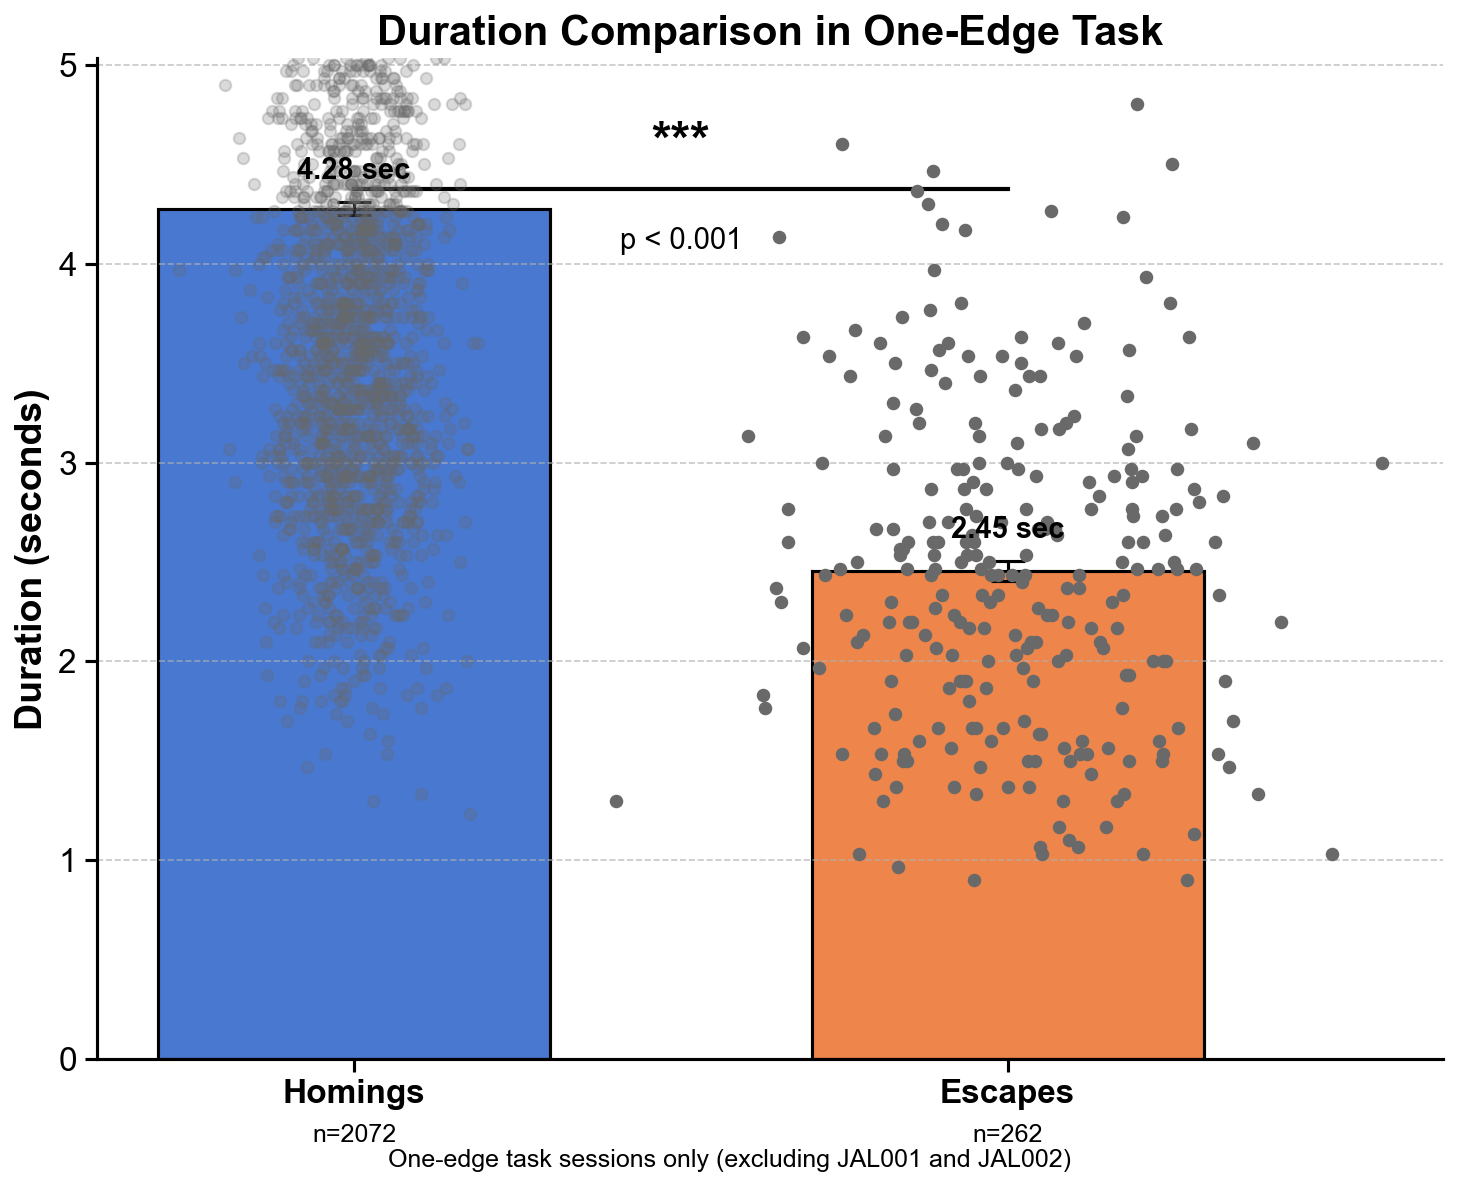

(array([4.63333333, 3.03333333, 4.33333333, ..., 2.2       , 3.36666667,
        3.23333333]),
 array([2.        , 1.66666667, 3.23333333, 3.73333333, 3.66666667,
        3.53333333, 2.96666667, 3.2       , 2.86666667, 3.8       ,
        2.53333333, 1.36666667, 1.46666667, 2.73333333, 1.7       ,
        2.43333333, 1.5       , 2.        , 1.1       , 2.33333333,
        3.7       , 3.6       , 3.5       , 2.26666667, 2.33333333,
        4.2       , 2.46666667, 3.1       , 1.3       , 2.06666667,
        1.56666667, 2.63333333, 1.03333333, 3.        , 2.3       ,
        3.43333333, 3.        , 3.26666667, 1.46666667, 2.2       ,
        3.13333333, 3.56666667, 2.13333333, 2.96666667, 3.13333333,
        3.        , 2.7       , 2.86666667, 3.63333333, 2.6       ,
        2.5       , 2.5       , 1.8       , 2.5       , 0.9       ,
        2.46666667, 4.26666667, 2.23333333, 3.53333333, 2.13333333,
        4.5       , 3.8       , 3.3       , 4.8       , 3.6       ,
        3.76666667, 3

In [39]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dill as pickle
from loguru import logger
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.rcParams.update({
    "font.size": 14,
    "font.family": "Arial",
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# Function to find all session directories
def find_all_sessions(base_path="Z:/Jasmine_Laurence/Experimental_Data"):
    """Find all session directories in the base path"""
    session_paths = []
    
    # Look for JAL directories
    mouse_dirs = glob.glob(os.path.join(base_path, "JAL*"))
    
    for mouse_dir in mouse_dirs:
        # Find all session directories within each mouse directory
        sessions = glob.glob(os.path.join(mouse_dir, "*"))
        for session in sessions:
            # Check if it's a directory and contains processed_data
            if os.path.isdir(session) and os.path.exists(os.path.join(session, "processed_data")):
                session_paths.append(session)
    
    return session_paths

# Function to load homings object
def load_homings_object(session_path):
    """Load homings object from a session"""
    homings_path = os.path.join(session_path, "processed_data", "homings", "homings_obj.pkl")
    
    if os.path.exists(homings_path):
        try:
            with open(homings_path, "rb") as f:
                return pickle.load(f)
        except Exception as e:
            logger.warning(f"Error loading homings object from {session_path}: {e}")
    
    return None

# Function to load escapes object
def load_escapes_object(session_path):
    """Load escapes object from a session, checking multiple possible paths"""
    possible_paths = [
        os.path.join(session_path, "processed_data", "escapes", "escapes_obj.pkl"),
        os.path.join(session_path, "processed_data", "escape", "escapes_obj.pkl"),
        os.path.join(session_path, "processed_data", "escapes_obj.pkl")
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    return pickle.load(f)
            except Exception as e:
                logger.warning(f"Error loading escapes object from {path}: {e}")
    
    return None

def compare_behavior_durations():
    """
    Compare the durations of homings vs escapes across all one-edge task sessions.
    Creates a bar plot comparing the distributions and performs statistical analysis.
    """
    # Find all session paths
    logger.info("Finding all session paths...")
    all_session_paths = find_all_sessions()
    logger.info(f"Found {len(all_session_paths)} session paths")
    
    # Filter to include only one-edge task sessions (exclude JAL001 and JAL002)
    session_paths = [s for s in all_session_paths if "JAL001" not in s and "JAL002" not in s]
    logger.info(f"Filtered to {len(session_paths)} one-edge task sessions")
    
    # Default FPS if not found in objects
    DEFAULT_FPS = 30.0
    
    # Collect durations for homings and escapes
    homings_durations = []  # in seconds
    escapes_durations = []  # in seconds
    
    # Process each session
    for session_path in session_paths:
        # Extract mouse name
        mouse_name = os.path.basename(os.path.dirname(session_path))
        session_name = os.path.basename(session_path)
        
        # Load homings object
        homings_obj = load_homings_object(session_path)
        if homings_obj is not None:
            # Get FPS from object if available
            fps = getattr(homings_obj, "fps", DEFAULT_FPS)
            
            if hasattr(homings_obj, "onset_frames") and hasattr(homings_obj, "offset_frames"):
                # Calculate durations in seconds
                for onset, offset in zip(homings_obj.onset_frames, homings_obj.offset_frames):
                    # Ensure we're working with scalar values
                    if hasattr(onset, "__len__"):
                        onset = onset[0]
                    if hasattr(offset, "__len__"):
                        offset = offset[0]
                    
                    duration_frames = offset - onset
                    duration_seconds = float(duration_frames) / fps
                    
                    if 0 < duration_seconds < 60:  # Filter out unrealistic durations
                        homings_durations.append(duration_seconds)
                
                logger.info(f"Added {len(homings_obj.onset_frames)} homing durations from {mouse_name}/{session_name}")
        
        # Load escapes object
        escapes_obj = load_escapes_object(session_path)
        if escapes_obj is not None:
            # Get FPS from object if available
            fps = getattr(escapes_obj, "fps", DEFAULT_FPS)
            
            if hasattr(escapes_obj, "escape_onset_frames") and hasattr(escapes_obj, "escape_end_frames"):
                # Calculate durations in seconds
                for onset, offset in zip(escapes_obj.escape_onset_frames, escapes_obj.escape_end_frames):
                    # Ensure we're working with scalar values
                    if hasattr(onset, "__len__"):
                        onset = onset[0]
                    if hasattr(offset, "__len__"):
                        offset = offset[0]
                    
                    duration_frames = offset - onset
                    duration_seconds = float(duration_frames) / fps
                    
                    if 0 < duration_seconds < 60:  # Filter out unrealistic durations
                        escapes_durations.append(duration_seconds)
                
                logger.info(f"Added {len(escapes_obj.escape_onset_frames)} escape durations from {mouse_name}/{session_name}")
    
    # Check if we have data to analyze
    if not homings_durations or not escapes_durations:
        logger.error("No duration data could be calculated for homings and/or escapes")
        print("\nPlease check if your objects have onset and offset frame attributes")
        return None, None
    
    # Debug: Check for non-scalar values before creating the array
    for i, val in enumerate(homings_durations):
        if hasattr(val, "__len__"):
            print(f"Warning: Found non-scalar value at index {i}: {val}")
            homings_durations[i] = float(val[0])  # Convert to scalar
    
    for i, val in enumerate(escapes_durations):
        if hasattr(val, "__len__"):
            print(f"Warning: Found non-scalar value at index {i}: {val}")
            escapes_durations[i] = float(val[0])  # Convert to scalar
    
    # Remove outliers using IQR method
    def remove_outliers(data):
        data = np.array(data, dtype=float)  # Ensure float dtype for consistent handling
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower = max(0, q1 - 1.5 * iqr)  # Ensure non-negative durations
        upper = q3 + 1.5 * iqr
        return data[(data >= lower) & (data <= upper)]
    
    homings_durations_clean = remove_outliers(homings_durations)
    escapes_durations_clean = remove_outliers(escapes_durations)
    
    # Print summary statistics
    print("\nDuration Summary Statistics (outliers removed):")
    print(f"Number of homings with duration data: {len(homings_durations_clean)}")
    print(f"Number of escapes with duration data: {len(escapes_durations_clean)}")
    print(f"Mean homing duration: {np.mean(homings_durations_clean):.2f} ± {np.std(homings_durations_clean):.2f} seconds")
    print(f"Mean escape duration: {np.mean(escapes_durations_clean):.2f} ± {np.std(escapes_durations_clean):.2f} seconds")
    print(f"Median homing duration: {np.median(homings_durations_clean):.2f} seconds")
    print(f"Median escape duration: {np.median(escapes_durations_clean):.2f} seconds")
    
    # Set publication-quality plot parameters
    plt.rcParams.update({
        "font.size": 16,
        "font.family": "Arial",
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "savefig.dpi": 300,
        "figure.dpi": 150
    })
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create bar plot with error bars
    behavior_types = ["Homings", "Escapes"]
    means = [np.mean(homings_durations_clean), np.mean(escapes_durations_clean)]
    sems = [np.std(homings_durations_clean)/np.sqrt(len(homings_durations_clean)), 
           np.std(escapes_durations_clean)/np.sqrt(len(escapes_durations_clean))]
    
    # Create bar plot with error bars
    bars = ax.bar(
        np.arange(len(behavior_types)), 
        means, 
        yerr=sems,
        width=0.6, 
        capsize=8, 
        color=['#4878D0', '#EE854A'], 
        edgecolor='black',
        linewidth=1.5,
        error_kw={'elinewidth': 1.5, 'capthick': 1.5}
    )
    
    # Add individual data points with jitter and transparency for dense data
    for i, (behavior, data) in enumerate(zip(behavior_types, [homings_durations_clean, escapes_durations_clean])):
        # Calculate jitter based on data size
        jitter_scale = min(0.2, 3.0/np.sqrt(len(data)))
        jitter = np.random.normal(0, jitter_scale, size=len(data))
        alpha = min(1.0, 500/len(data))  # Reduce opacity when many points
        
        ax.scatter(
            i + jitter, 
            data, 
            color='dimgrey', 
            alpha=alpha, 
            s=30, 
            zorder=3
        )
    
    # Perform statistical test (Mann-Whitney U test for non-parametric comparison)
    from scipy.stats import mannwhitneyu
    stat_result = mannwhitneyu(homings_durations_clean, escapes_durations_clean)
    p_value = stat_result.pvalue
    
    # Add statistical annotation
    if p_value < 0.001:
        significance = "***"
    elif p_value < 0.01:
        significance = "**"
    elif p_value < 0.05:
        significance = "*"
    else:
        significance = "n.s."
    
    # Calculate position for significance bar
    y_max = max(means) + max(sems) * 2
    ax.plot([0, 1], [y_max, y_max], 'k-', linewidth=2)
    ax.text(0.5, y_max * 1.05, significance, ha='center', va='center', fontsize=24, fontweight='bold')
    
    # Add exact p-value
    p_text = f"p = {p_value:.3f}" if p_value >= 0.001 else "p < 0.001"
    ax.text(0.5, y_max * 0.94, p_text, ha='center', va='center', fontsize=14)
    
    # Add value labels on top of bars
    for i, (bar, mean, sem) in enumerate(zip(bars, means, sems)):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean + sem + (max(means) * 0.02),
            f"{mean:.2f} sec",
            ha='center',
            va='bottom',
            fontsize=14,
            fontweight='bold'
        )
    
    # Set axis labels and title
    ax.set_ylabel("Duration (seconds)", fontweight='bold')
    ax.set_xlabel("")
    ax.set_title("Duration Comparison in One-Edge Task", fontweight="bold")
    ax.set_xticks(np.arange(len(behavior_types)))
    ax.set_xticklabels(behavior_types, fontweight='bold')
    
    # Set y-axis limits with some padding
    ax.set_ylim(0, y_max * 1.15)
    
    # Add sample size info
    ax.text(0, -0.05, f"n={len(homings_durations_clean)}", ha='center', va='top', 
            transform=ax.get_xticklabels()[0].get_transform(), fontsize=12)
    ax.text(1, -0.05, f"n={len(escapes_durations_clean)}", ha='center', va='top', 
            transform=ax.get_xticklabels()[1].get_transform(), fontsize=12)
    
    # Add note about data source
    plt.figtext(0.5, 0.01, "One-edge task sessions only (excluding JAL001 and JAL002)", 
               ha='center', fontsize=12)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=6)
    
    # Add grid lines for y-axis only
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    # Tight layout
    plt.tight_layout()
    
    # Save the figure
    save_path = r"Z:\Laurence\thesis\figures\homings"
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, "duration_comparison.eps"), format='eps', bbox_inches='tight')
    plt.savefig(os.path.join(save_path, "duration_comparison.png"), format='png', bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(save_path, "duration_comparison.pdf"), format='pdf', bbox_inches='tight')
    
    plt.show()
    
    return homings_durations_clean, escapes_durations_clean

compare_behavior_durations()